#Mammography project:Breast Cancer Detection

The dataset used in this project was self-generated through a series of image processing techniques applied to mammographic images. These preprocessing steps, including contrast enhancement, denoising, and feature extraction, are detailed in a separate Jupyter Colab notebook. After processing, a CSV file containing the extracted features was created and used for further analysis. Both the image processing notebook and the resulting dataset are available in the associated GitHub repository: https://github.com/marlefuhr/Advanced-Biomedical-Image-Processing-

The images are from MIAS dataset and can be accesed using the following link:http://peipa.essex.ac.uk/pix/mias/Info.txt

#Pre-processing and Data Pre-processing

Mount google drive

In [5]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The dataset is imported from a specified path using pandas, and the first few rows are displayed to inspect the structure and contents.

In [6]:

path_to_data_folder = "/content/drive/MyDrive/Machine Learning for Data Science/Ex3  presentation/Project/features - features.csv"

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(path_to_data_folder)
df.head()

,Image_ID,Contrast,Correlation,Energy,Homogeneity,Mean_Intensity,Std_Intensity,Skew_Intensity,Circularity,Eccentricity,Perimeter,background tissue,class of abnormality,severity,radius of circle
0,0,24.538.529.607.321.600,9.976.113.048.817.470,5.494.976.625.526.270,808.655.422.186.839,4.540.583.740.234.370,7.164.064.386.659.320,14.394.142.436.824.900,7.657.209.911.882.290,9.259.469.768.611.270,5.656.582.274.794.570,G,CIRC,B,69.0
1,1,20.170.691.880.475.500,9.983.282.544.876.220,5.982.862.564.507.760,8.302.225.607.097.860,4.655.466.186.523.430,776.390.755.836.946,1.436.722.613.044.810,33.451.680.607.011.200,8.918.793.255.927.660,26.423.413.898.944.800,D,NORM,NaN,NaN
2,2,3.201.539.522.058.820,9.968.912.125.886.360,5.422.775.516.361.450,7.736.155.182.860.450,49.463.660.888.671.800,7.173.263.664.426.210,10.664.511.716.804.400,33.140.809.053.782.300,9.004.790.891.916.740,30.125.495.409.965.500,F,NORM,NaN,NaN
3,3,3.501.543.188.751.560,9.962.070.693.335.490,5.291.128.811.033.990,7.925.812.064.196.750,477.930.859.375,6.791.763.765.357.140,9.729.840.986.128.800,3.362.101.468.949.210,8.928.127.355.028.890,30.088.683.010.339.700,G,NORM,NaN,NaN
4,4,31.501.284.564.690.200,996.627.354.701.788,6.148.084.845.744.550,8.206.277.044.074.260,413.434.326.171.875,683.098.859.849.417,13.714.339.381.616,30.331.054.192.265.200,9.209.939.222.935.510,2.792.642.906.188.960,F,NORM,NaN,NaN


Providing info on dataset and seeing the type for each feature

In [7]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Image_ID              108 non-null    int64  
 1   Contrast              108 non-null    object 
 2   Correlation           108 non-null    object 
 3   Energy                108 non-null    object 
 4   Homogeneity           108 non-null    object 
 5   Mean_Intensity        108 non-null    object 
 6   Std_Intensity         108 non-null    object 
 7   Skew_Intensity        108 non-null    object 
 8   Circularity           108 non-null    object 
 9   Eccentricity          108 non-null    object 
 10  Perimeter             108 non-null    object 
 11  background tissue     108 non-null    object 
 12  class of abnormality  108 non-null    object 
 13  severity              35 non-null     object 
 14  radius of circle      34 non-null     float64
dtypes: float64(1), int64(1)

Remove Image_ID and any column that has more than 30% of missing data

In [8]:

df2 = df[[column for column in df if df[column].count() / len(df) >= 0.3]]
del df2['Image_ID']
print("List of dropped columns:", end=" ")
for c in df.columns:
    if c not in df2.columns:
        print(c, end=", ")
print('\n')
df = df2

List of dropped columns: Image_ID, 



Converting object type columns to integers by removing periods

In [9]:

exclude_columns = ["background tissue", "class of abnormality", "severity"]
numeric_columns = [col for col in df.columns if col not in exclude_columns]

for col in numeric_columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(".", "", regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce', downcast='integer')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Contrast              108 non-null    int64  
 1   Correlation           108 non-null    int64  
 2   Energy                108 non-null    int64  
 3   Homogeneity           108 non-null    int64  
 4   Mean_Intensity        108 non-null    int64  
 5   Std_Intensity         108 non-null    int64  
 6   Skew_Intensity        108 non-null    int64  
 7   Circularity           108 non-null    int64  
 8   Eccentricity          108 non-null    int64  
 9   Perimeter             108 non-null    int64  
 10  background tissue     108 non-null    object 
 11  class of abnormality  108 non-null    object 
 12  severity              35 non-null     object 
 13  radius of circle      34 non-null     float64
dtypes: float64(1), int64(10), object(3)
memory usage: 11.9+ KB


Calculating if there is missing data as NaN

In [11]:
df.isnull().sum()

,0
Contrast,0
Correlation,0
Energy,0
Homogeneity,0
Mean_Intensity,0
Std_Intensity,0
Skew_Intensity,0
Circularity,0
Eccentricity,0
Perimeter,0


Plot histograms for numeric features

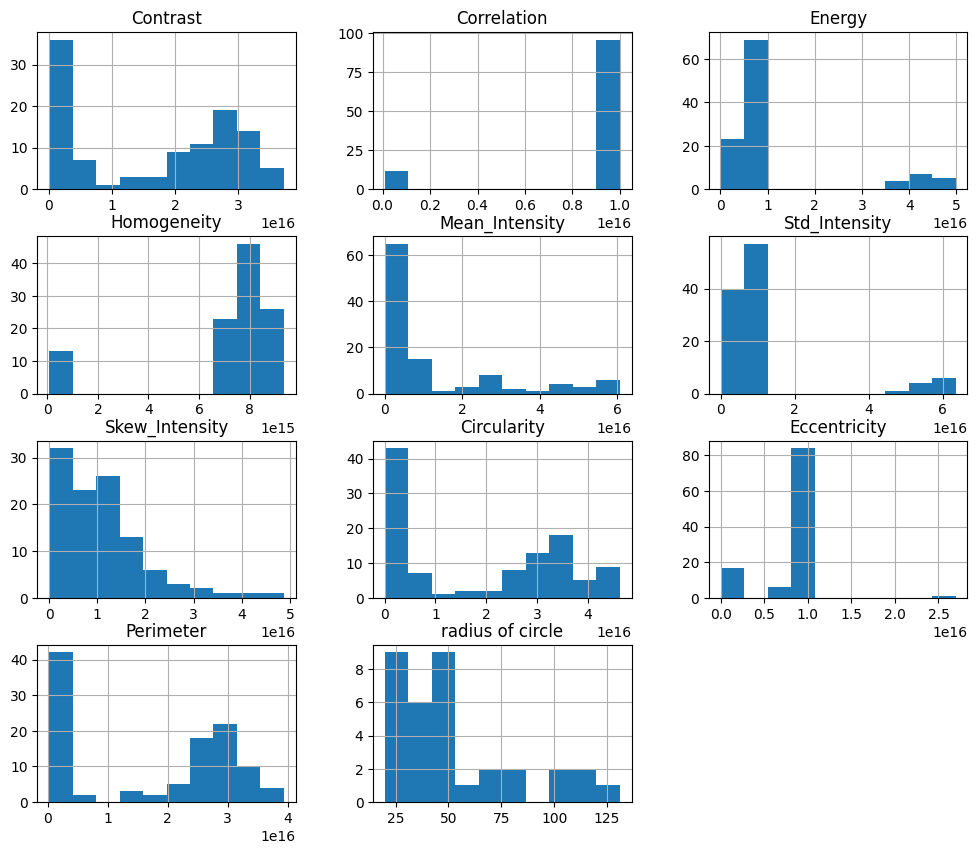

In [12]:

df.hist(figsize=(12, 10))
plt.show()

This shows that many of the features of the dataset don't have numerical values.

In [13]:
df_cate = df.select_dtypes(include = ['O'])
print('There is {} non numerical features including:\n{}'.format(len(df_cate.columns), df_cate.columns.tolist()))

There is 3 non numerical features including:
['background tissue', 'class of abnormality', 'severity']


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

Plotting the categorical features

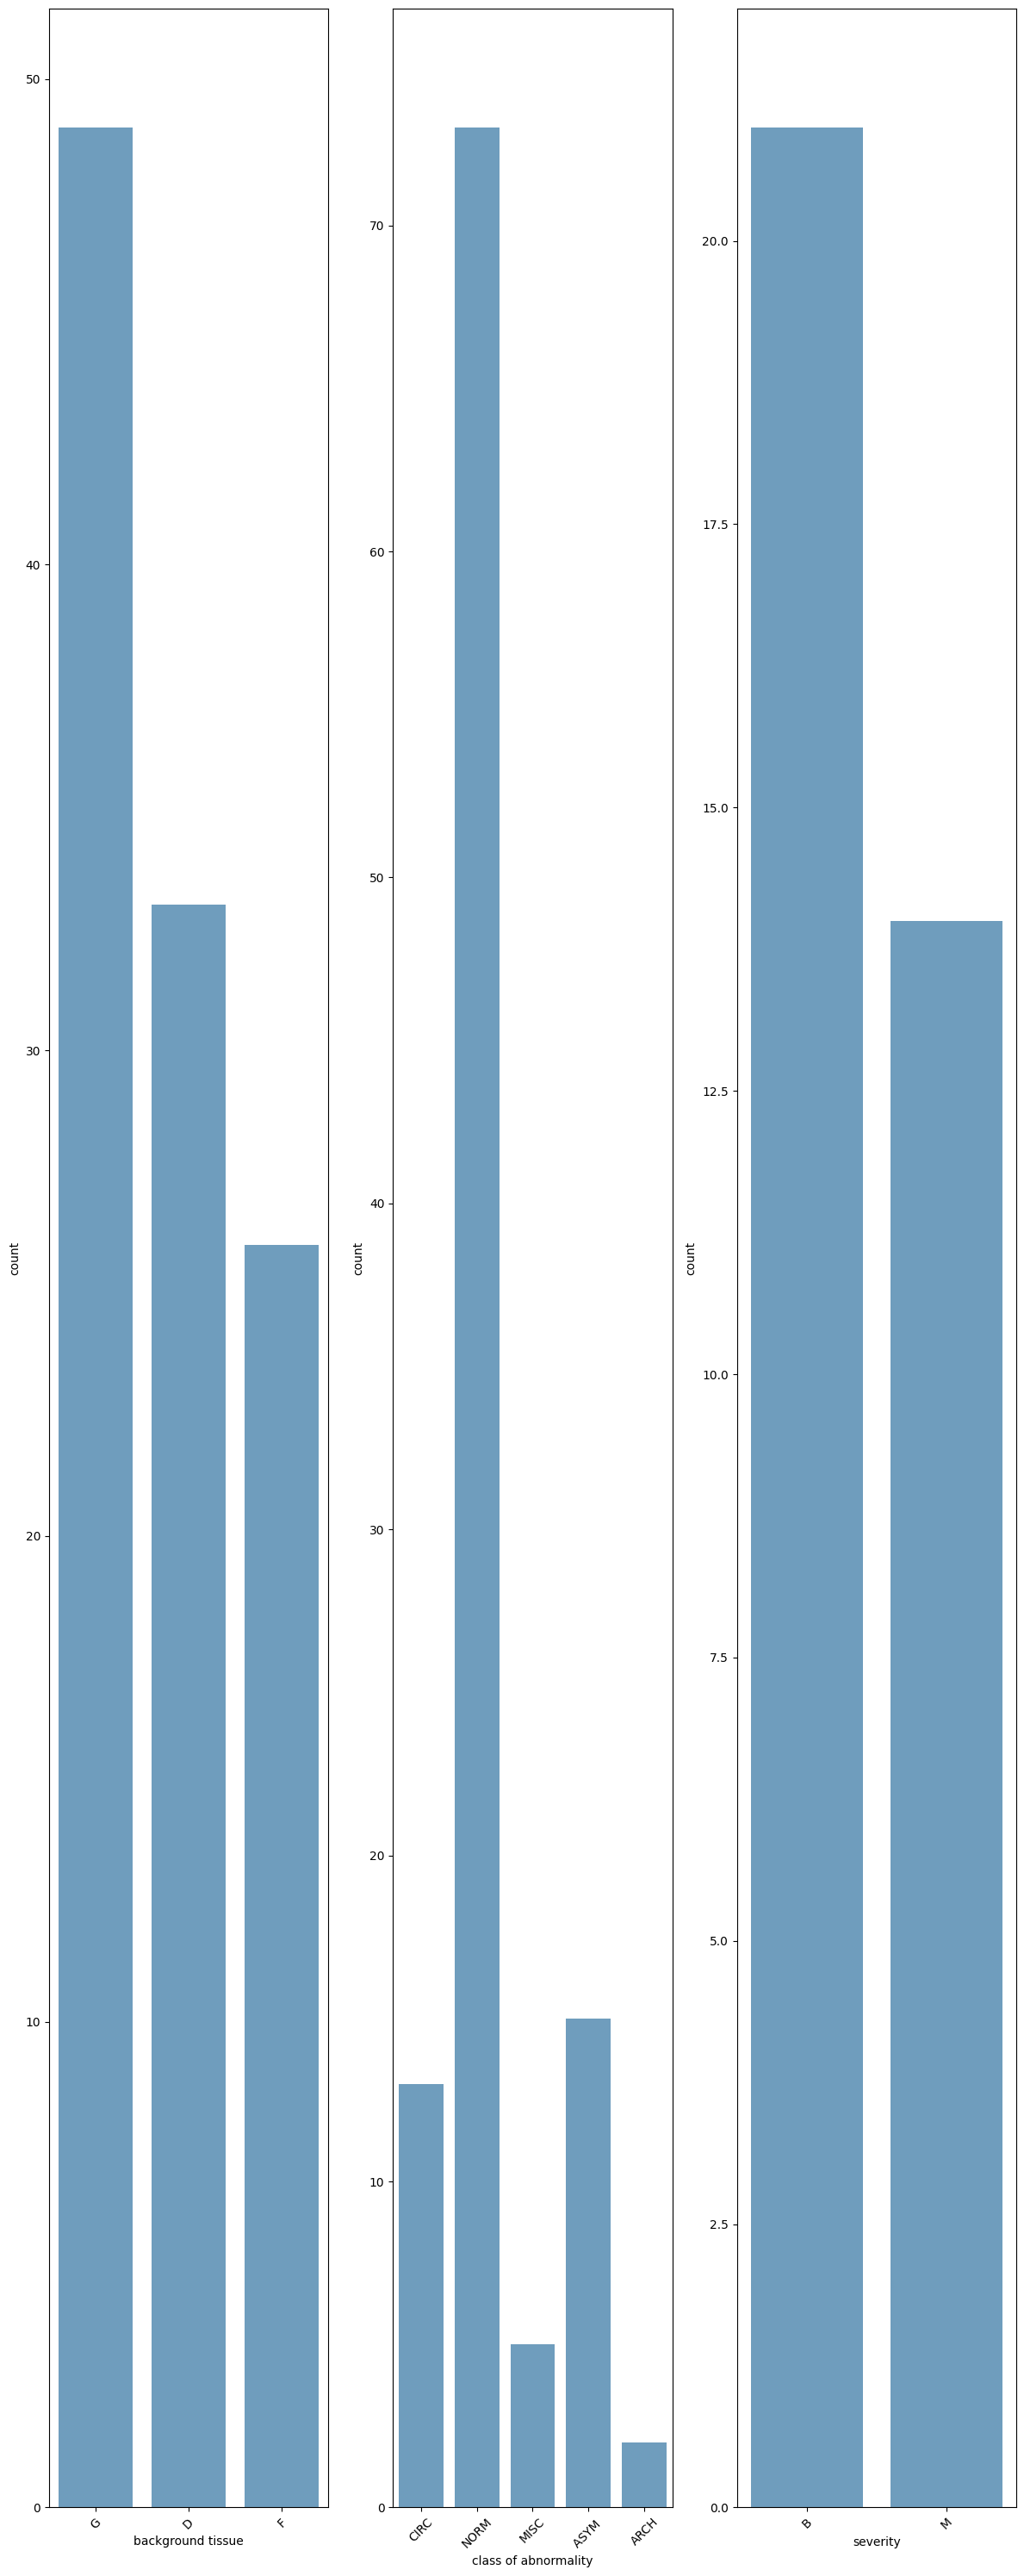

In [15]:
fig, axes = plt.subplots(round(len(df_cate.columns) / 3), 3, figsize=(12, 30))

for i, ax in enumerate(fig.axes):
    if i < len(df_cate.columns):
        ax.tick_params(axis='x', rotation=45)
        sns.countplot(x=df_cate.columns[i], alpha=0.7, data=df_cate, ax=ax)

fig.tight_layout()

Mapping ordinal features: Categorical to numerical

The Severity variable was encoded as 0 for normal, 1 for benign, and 2 for malignant. Missing values (NaN) in the Severity column were imputed with 0, as they correspond to normal tissue.

In [17]:
severity_mapping = {'B': 1, 'M': 2, np.nan: 0}
df['severity'] = df['severity'].map(severity_mapping)


My mission is to predict if a tumor es Benign (B), Malignant (M) or Normal (NaN).

For the categorical variables, I am changing it in to its own variable in boolean style(True or False/1 or 0).

In [18]:

df_encoded = pd.get_dummies(df, columns=['background tissue', 'class of abnormality'])

df_encoded[df_encoded.columns[df_encoded.dtypes == 'bool']] = df_encoded[df_encoded.columns[df_encoded.dtypes == 'bool']].astype(int)

print(df_encoded.head())

            Contrast       Correlation            Energy       Homogeneity  \
0  24538529607321600  9976113048817470  5494976625526270   808655422186839   
1  20170691880475500  9983282544876220  5982862564507760  8302225607097860   
2   3201539522058820  9968912125886360  5422775516361450  7736155182860450   
3   3501543188751560  9962070693335490  5291128811033990  7925812064196750   
4  31501284564690200   996627354701788  6148084845744550  8206277044074260   

      Mean_Intensity     Std_Intensity     Skew_Intensity        Circularity  \
0   4540583740234370  7164064386659320  14394142436824900   7657209911882290   
1   4655466186523430   776390755836946   1436722613044810  33451680607011200   
2  49463660888671800  7173263664426210  10664511716804400  33140809053782300   
3       477930859375  6791763765357140   9729840986128800   3362101468949210   
4    413434326171875   683098859849417     13714339381616  30331054192265200   

       Eccentricity          Perimeter  severity  

In [19]:
df_encoded.head()

,Contrast,Correlation,Energy,Homogeneity,Mean_Intensity,Std_Intensity,Skew_Intensity,Circularity,Eccentricity,Perimeter,severity,radius of circle,background tissue_D,background tissue_F,background tissue_G,class of abnormality_ARCH,class of abnormality_ASYM,class of abnormality_CIRC,class of abnormality_MISC,class of abnormality_NORM
0,24538529607321600,9976113048817470,5494976625526270,808655422186839,4540583740234370,7164064386659320,14394142436824900,7657209911882290,9259469768611270,5656582274794570,1,69.0,0,0,1,0,0,1,0,0
1,20170691880475500,9983282544876220,5982862564507760,8302225607097860,4655466186523430,776390755836946,1436722613044810,33451680607011200,8918793255927660,26423413898944800,0,NaN,1,0,0,0,0,0,0,1
2,3201539522058820,9968912125886360,5422775516361450,7736155182860450,49463660888671800,7173263664426210,10664511716804400,33140809053782300,9004790891916740,30125495409965500,0,NaN,0,1,0,0,0,0,0,1
3,3501543188751560,9962070693335490,5291128811033990,7925812064196750,477930859375,6791763765357140,9729840986128800,3362101468949210,8928127355028890,30088683010339700,0,NaN,0,0,1,0,0,0,0,1
4,31501284564690200,996627354701788,6148084845744550,8206277044074260,413434326171875,683098859849417,13714339381616,30331054192265200,9209939222935510,2792642906188960,0,NaN,0,1,0,0,0,0,0,1


Now I impute the missing data : For the radius of the circle, I change NaN with the value zero since it has a radius of zero since it is normal (non cancirnoma tissue)

In [20]:

df_encoded['radius of circle'] = df_encoded['radius of circle'].fillna(0)

In [21]:
df_encoded['radius of circle'].head()

,radius of circle
0,69.0
1,0.0
2,0.0
3,0.0
4,0.0


Check remaining missing values if any

In [22]:

df_na = (df.isnull().sum() / len(df)) * 100
df_na = df_na.drop(df_na[df_na == 0].index).sort_values(ascending=False)
missing_data = pd.DataFrame({'Missing Ratio' :df_na})
missing_data.head()

,Missing Ratio
radius of circle,68.518519


Now we can see that there is no missing data

In [23]:
df_encoded.isnull().sum()

,0
Contrast,0
Correlation,0
Energy,0
Homogeneity,0
Mean_Intensity,0
Std_Intensity,0
Skew_Intensity,0
Circularity,0
Eccentricity,0
Perimeter,0


So we can see there are no missing values.

Now we can plot the heatmap to see the numerical correlations.

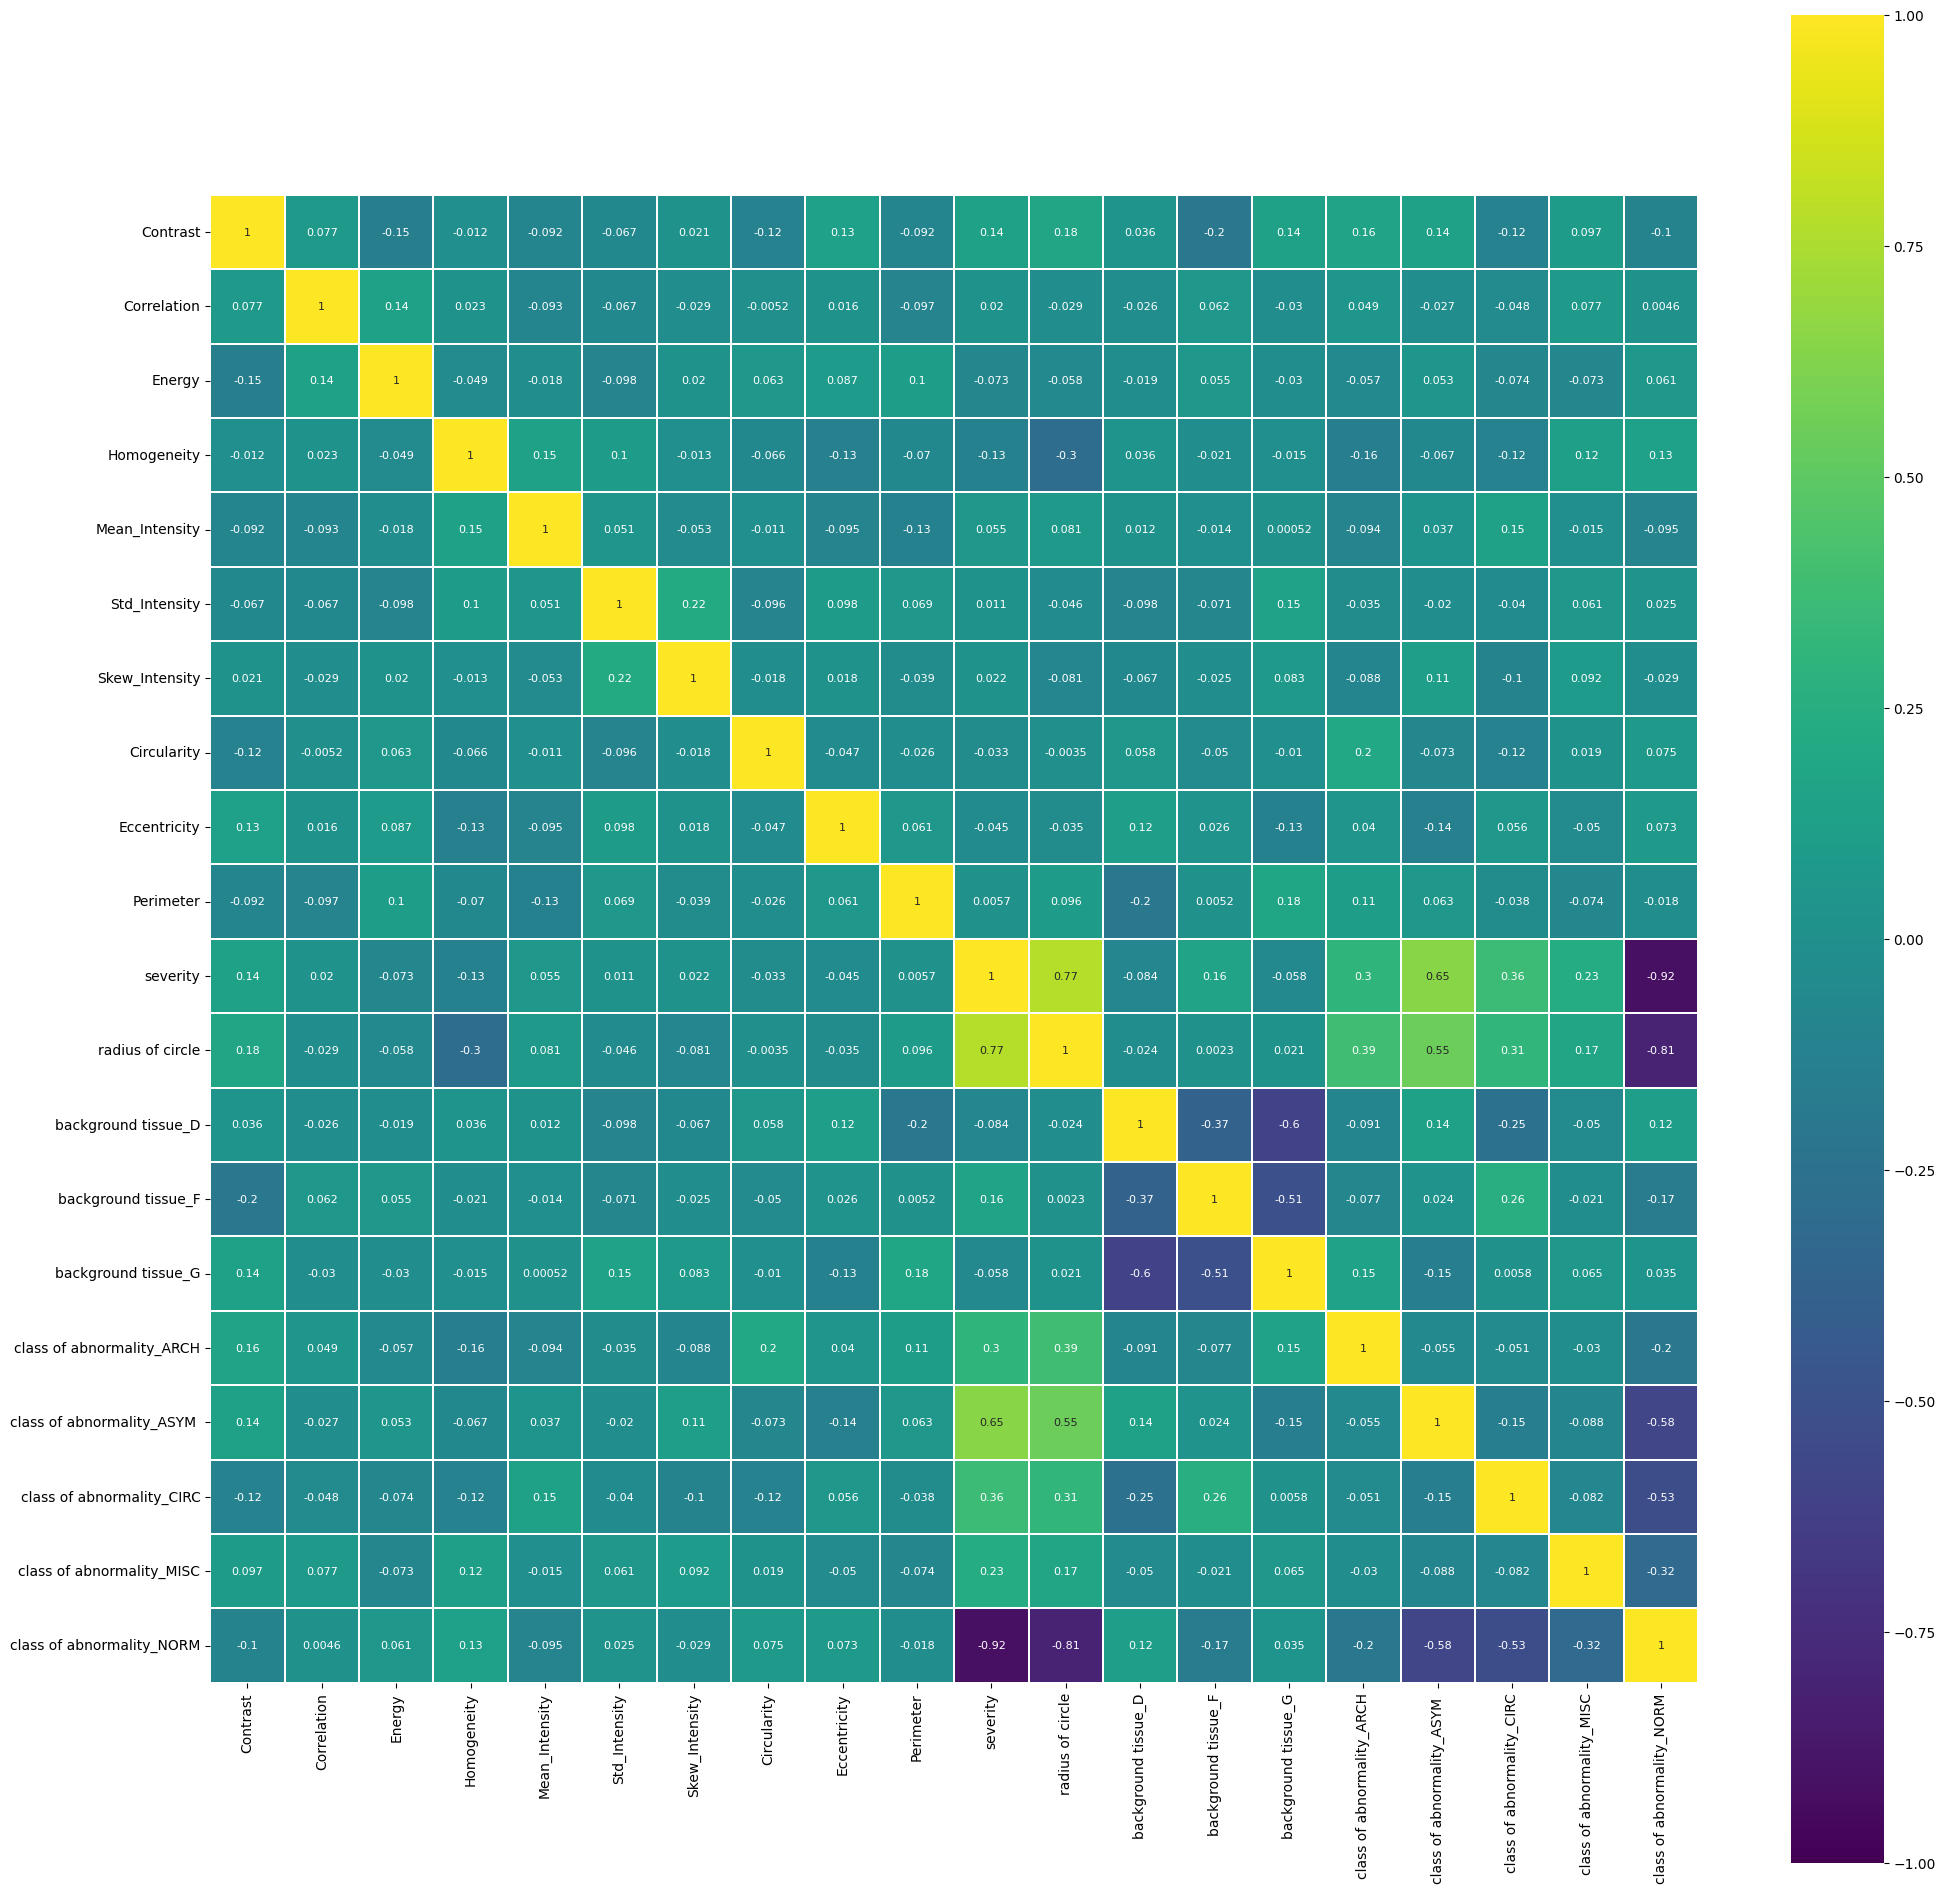

In [24]:

df_corr = df_encoded.select_dtypes(include=['number']).corr()
plt.figure(figsize=(24, 24))

sns.heatmap(df_corr,
            cmap='viridis', vmax=1.0, vmin=-1.0, linewidths=0.1,
            annot=True, annot_kws={"size": 8}, square=True);

I calculate the correlations with severity

In [25]:

df_corr = df_encoded.corr(numeric_only=True)


severity_corr = df_corr['severity'].drop('severity')  # Exclude self-correlation


golden_features_list = severity_corr[abs(severity_corr) > 0.5].sort_values(ascending=False)
print("There are {} correlated values with severity:\n{}".format(len(golden_features_list), golden_features_list))

There are 3 correlated values with severity:
radius of circle              0.773543
class of abnormality_ASYM     0.646469
class of abnormality_NORM    -0.920123
Name: severity, dtype: float64


#tsne

The t-SNE visualization provides a qualitative understanding of how separable the classes are in the feature space before modeling. When examining the left plot, which shows the original dataset prior to applying SMOTE, a significant class imbalance is evident. Class 0 (normal, shown in blue) dominates the feature space, while Classes 1 (benign, orange) and 2 (malignant, green) have far fewer samples and are scattered sparsely. This leads to overlapping clusters and poor separation between classes, with Class 0 overlapping heavily with the other two. Such class overlap indicates that models like Logistic Regression may struggle, particularly due to its assumption of linear separability, and are likely to overfit to the majority class.

After applying SMOTE, as shown in the right plot, the data becomes more balanced, with each class having roughly equal density. SMOTE effectively generates synthetic examples for the minority classes, which leads to better-defined clusters. While some overlap remains, the spatial separation is significantly improved. This makes it easier for models to learn from a fair representation of all classes, particularly benefiting minority class performance. The t-SNE after SMOTE shows fairly compact clusters, especially for benign and malignant cases, but also reveals that the boundaries between classes are nonlinear and somewhat curved.

This observation supports the expectation that nonlinear models will perform better. Random Forests are well-suited for such data because they partition the feature space hierarchically and do not assume linearity. They also handle imbalanced data well, especially after SMOTE, and provide interpretable feature importance scores. Support Vector Machines (SVMs) with nonlinear kernels like RBF are also expected to perform strongly. They are effective in high-dimensional spaces and can capture the nonlinear boundaries seen in the t-SNE plot, though they require careful tuning of hyperparameters like C and gamma. Neural Networks offer the flexibility to model complex decision boundaries and are commonly used in medical imaging tasks, but they require sufficient data, appropriate regularization, and tuning to avoid overfitting, especially when class separation is not perfect. Lastly, Logistic Regression is expected to perform the weakest, given that it assumes linear separability, which is not supported by the structure revealed in the t-SNE plots. It is still useful as a baseline due to its simplicity and interpretability.









/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
<ipython-input-66-73cff95fdd25>:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = get_cmap("tab10")


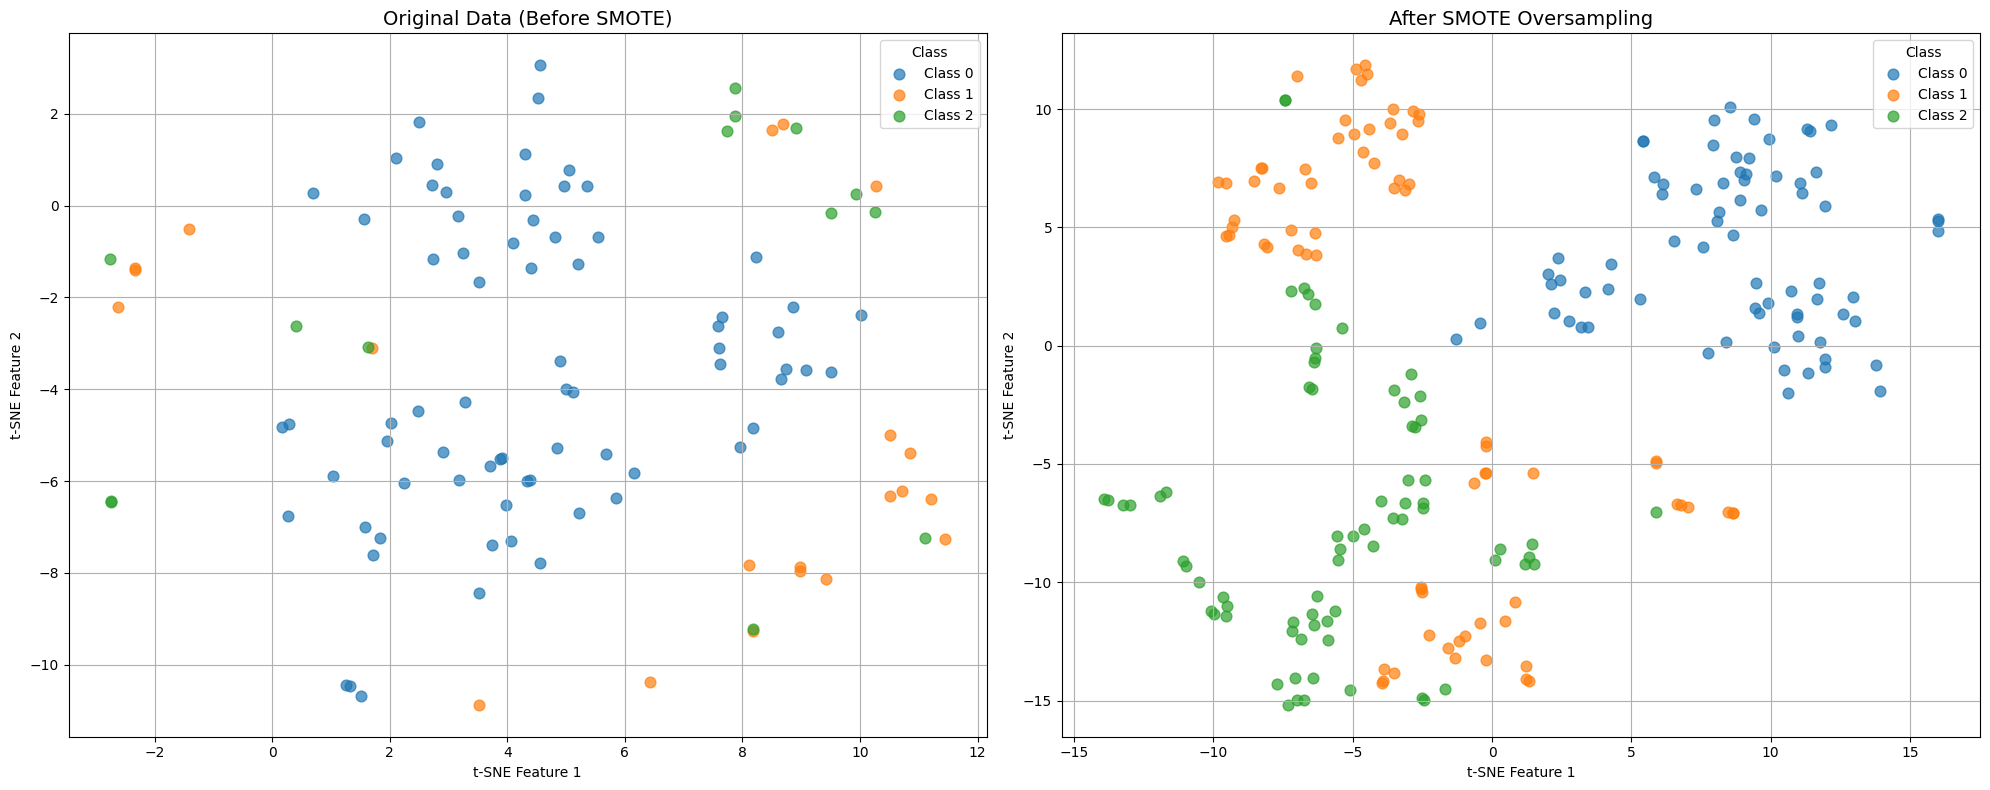

In [66]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import numpy as np


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)


tsne = TSNE(random_state=42, perplexity=30, learning_rate=200, n_iter=2000, init='pca')
X_tsne_original = tsne.fit_transform(X_scaled)
X_tsne_smote = tsne.fit_transform(X_resampled)


colors = get_cmap("tab10")
unique_classes = np.unique(y)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))


axes[0].set_title("Original Data (Before SMOTE)", fontsize=14)
for i, cls in enumerate(unique_classes):
    idx = np.where(y == cls)
    axes[0].scatter(X_tsne_original[idx, 0], X_tsne_original[idx, 1],
                    label=f"Class {cls}", alpha=0.7, s=60, color=colors(i))
axes[0].set_xlabel("t-SNE Feature 1")
axes[0].set_ylabel("t-SNE Feature 2")
axes[0].legend(title="Class", loc="best")
axes[0].grid(True)


axes[1].set_title("After SMOTE Oversampling", fontsize=14)
for i, cls in enumerate(unique_classes):
    idx = np.where(y_resampled == cls)
    axes[1].scatter(X_tsne_smote[idx, 0], X_tsne_smote[idx, 1],
                    label=f"Class {cls}", alpha=0.7, s=60, color=colors(i))
axes[1].set_xlabel("t-SNE Feature 1")
axes[1].set_ylabel("t-SNE Feature 2")
axes[1].legend(title="Class", loc="best")
axes[1].grid(True)

plt.tight_layout()
plt.show()


#Features Engineering

Calculating the skewed features

In [26]:
from scipy.stats import skew

numeric_feats = df_encoded.dtypes[df_encoded.dtypes != "object"].index

skewed_feats = df_encoded[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)

skewness = pd.DataFrame({'Skew' : skewed_feats})
print("\nSkew in numerical features: \n")
print(skewness.head(10))



Skew in numerical features: 

                                Skew
class of abnormality_ARCH   7.142749
class of abnormality_MISC   4.318396
Std_Intensity               2.566581
class of abnormality_CIRC   2.333353
class of abnormality_ASYM   2.088370
radius of circle            1.976378
Energy                      1.966405
Mean_Intensity              1.563554
Skew_Intensity              1.491503
severity                    1.240134


these features are highly skewed (with a skewness greater than 0.75) so I did Box Cox transformation

In [27]:
from scipy.stats import skew
from scipy.special import boxcox1p

numeric_feats = df_encoded.dtypes[df_encoded.dtypes != "object"].index

numeric_feats = [feat for feat in numeric_feats if feat != 'severity']

skewed_feats = df_encoded[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
print("\nSkew in numerical features: \n")
skewness = pd.DataFrame({'Skew' : skewed_feats})
skewness.head(10)

skewness = skewness[abs(skewness) > 0.75]
print("There are {} skewed numerical features to Box Cox transform".format(skewness.shape[0]))

skewed_features = skewness.index
lam = 0.15
for feat in skewed_features:
    df_encoded[feat] = boxcox1p(df_encoded[feat], lam)

df_encoded.head()



Skew in numerical features: 

There are 19 skewed numerical features to Box Cox transform


,Contrast,Correlation,Energy,Homogeneity,Mean_Intensity,Std_Intensity,Skew_Intensity,Circularity,Eccentricity,Perimeter,severity,radius of circle,background tissue_D,background tissue_F,background tissue_G,class of abnormality_ARCH,class of abnormality_ASYM,class of abnormality_CIRC,class of abnormality_MISC,class of abnormality_NORM
0,1909.291495,1667.323665,1524.081043,1141.680667,1480.896767,1586.211880,1761.961798,1602.197296,1648.709350,1530.750964,1,5.942124,0.000000,0.000000,0.730463,0.0,0.0,0.730463,0.0,0.000000
1,1853.778439,1667.504066,1543.738100,1621.833925,1486.482573,1134.688461,1245.074917,2000.444523,1639.427423,1930.678841,0,0.000000,0.730463,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.730463
2,1404.936328,1667.142362,1521.047074,1604.674553,2121.725635,1586.518521,1684.163109,1997.635551,1641.798542,1969.160127,0,0.000000,0.000000,0.730463,0.000000,0.0,0.0,0.000000,0.0,0.730463
3,1424.030325,1666.970007,1515.425641,1610.539194,369.875400,1573.511754,1661.058960,1415.335845,1639.685719,1968.797780,0,0.000000,0.000000,0.000000,0.730463,0.0,0.0,0.000000,0.0,0.730463
4,1982.439577,1178.252328,1550.086360,1618.996879,1031.745387,1112.980731,616.328927,1971.176571,1647.378085,1376.297896,0,0.000000,0.000000,0.730463,0.000000,0.0,0.0,0.000000,0.0,0.730463


Splitting the train and test sets

#Modelling

The dataset used in this study is imbalanced, with a clear dominance of Normal cases, which comprise approximately 67% of the training set and 68% of the test set. Benign and Malignant classes are underrepresented, making up only around 19% and 13% of the training data, and 18% and 14% of the test data, respectively. To preserve this class distribution across subsets, stratification was applied during the train-test split. This ensures that each class is proportionally represented, minimizing sampling bias and providing a more reliable basis for evaluation. However, the imbalance in the dataset can cause models to become biased towards the majority class (Normal) leading to poor sensitivity in detecting Benign and Malignant cases.

To mitigate this, the data was standardized using feature scaling, which ensures that all features contribute equally to model training. Logistic Regression was applied to handle the multiclass classification problem effectively. Evaluation was performed using accuracy scores and classification reports. Despite these efforts, the limited number of samples,only 41 Normal, 11 Benign, and 8 Malignant,poses a risk of overfitting, particularly in the minority classes. This data scarcity highlights the need for techniques like SMOTE and robust validation to ensure generalizable results.

##Feature Selectiton decision

I decided to do Sequential Feature Seelction and Mutual Information to a basic code of Logistic Regression to see which one performs better.

SBS: Sequential feature Selection class

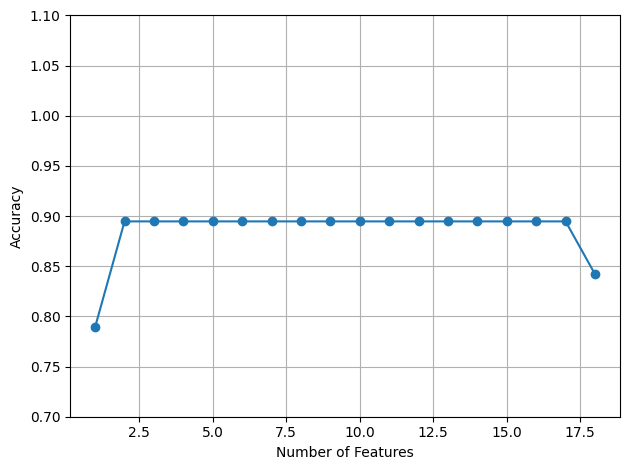

Best features: Index(['Contrast', 'Correlation', 'Energy', 'Homogeneity', 'Mean_Intensity',
       'Std_Intensity', 'Circularity', 'class of abnormality_ASYM ',
       'class of abnormality_CIRC', 'class of abnormality_MISC'],
      dtype='object')
Training Accuracy with selected features: 0.8933
Test Accuracy with selected features: 0.9091


In [36]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt


class SBS():
    def __init__(self, estimator, k_features, scoring=accuracy_score, test_size=0.25, random_state=1):
        self.scoring = scoring
        self.estimator = clone(estimator)
        self.k_features = k_features
        self.test_size = test_size
        self.random_state = random_state

    def fit(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=self.test_size, random_state=self.random_state)
        dim = X_train.shape[1]
        self.indices_ = tuple(range(dim))
        self.subsets_ = [self.indices_]
        score = self._calc_score(X_train, y_train, X_test, y_test, self.indices_)
        self.scores_ = [score]

        while dim > self.k_features:
            scores = []
            subsets = []

            for p in combinations(self.indices_, r=dim - 1):
                score = self._calc_score(X_train, y_train, X_test, y_test, p)
                scores.append(score)
                subsets.append(p)

            best = np.argmax(scores)
            self.indices_ = subsets[best]
            self.subsets_.append(self.indices_)
            dim -= 1

            self.scores_.append(scores[best])
        self.k_score_ = self.scores_[-1]

        return self

    def transform(self, X):
        return X[:, self.indices_]

    def _calc_score(self, X_train, y_train, X_test, y_test, indices):
        self.estimator.fit(X_train[:, indices], y_train)
        y_pred = self.estimator.predict(X_test[:, indices])
        score = self.scoring(y_test, y_pred)
        return score


sbs = SBS(log_reg, k_features=1)
sbs.fit(X_train_scaled, y_train)

k_feat = [len(k) for k in sbs.subsets_]

plt.plot(k_feat, sbs.scores_, marker='o')
plt.ylim([0.7, 1.1])
plt.ylabel('Accuracy')
plt.xlabel('Number of Features')
plt.grid()
plt.tight_layout()
plt.show()

k_best_features = list(sbs.subsets_[8])
print("Best features:", X.columns[k_best_features])

log_reg.fit(X_train_scaled[:, k_best_features], y_train)
print(f"Training Accuracy with selected features: {log_reg.score(X_train_scaled[:, k_best_features], y_train):.4f}")
print(f"Test Accuracy with selected features: {log_reg.score(X_test_scaled[:, k_best_features], y_test):.4f}")


Mutual Information

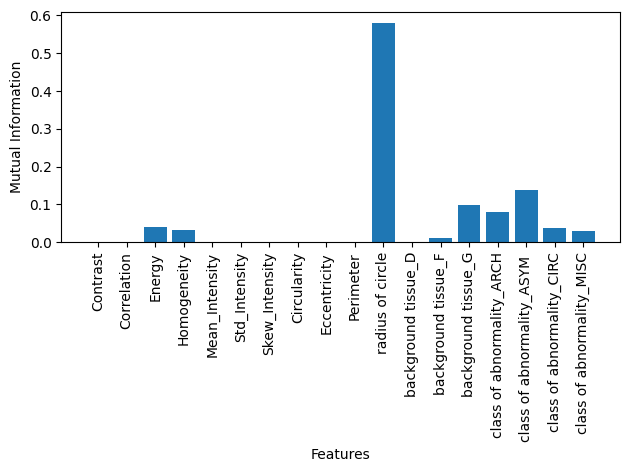

Training Accuracy with selected features: 0.8933
Test Accuracy with selected features: 0.8788

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       0.71      0.71      0.71         7
           2       0.50      0.50      0.50         4

    accuracy                           0.88        33
   macro avg       0.74      0.74      0.74        33
weighted avg       0.88      0.88      0.88        33



In [37]:

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt

# **Step 1: Calculate Mutual Information**
# We calculate mutual information between each feature and the target 'severity'
mi = mutual_info_classif(X_train_scaled, y_train)

# **Step 2: Plot Mutual Information Scores**
# Create a bar plot for mutual information scores of each feature
plt.bar(X_train.columns, mi)
plt.xlabel('Features')
plt.ylabel('Mutual Information')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# **Step 3: Select features based on Mutual Information**
# Let's assume you want to select the top k features based on mutual information scores
k_best = 5  # Number of top features to select
top_k_features = np.argsort(mi)[-k_best:]  # Get the indices of the top k features

# **Step 4: Train Model with Selected Features**
# Train logistic regression model using only the top k features selected based on MI
log_reg = LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=5000, C=0.1)

log_reg.fit(X_train_scaled[:, top_k_features], y_train)
y_pred = log_reg.predict(X_test_scaled[:, top_k_features])

# **Step 5: Model Evaluation**
# Evaluate the model using classification report and accuracy score
print(f"Training Accuracy with selected features: {log_reg.score(X_train_scaled[:, top_k_features], y_train):.4f}")
print(f"Test Accuracy with selected features: {log_reg.score(X_test_scaled[:, top_k_features], y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


I decided to use Sequential Backward Selection (SBS) moving forward, as it consistently yielded better results. Given the relatively small number of features in the dataset, the added complexity of using Mutual Information was not justified.

##SMOTE

In [38]:
from sklearn.metrics import accuracy_score, f1_score


In [40]:
from collections import Counter


Class distribution BEFORE SMOTE: Counter({0: 43, 1: 13, 2: 8})
Class distribution AFTER SMOTE: Counter({0: 43, 1: 43, 2: 43})


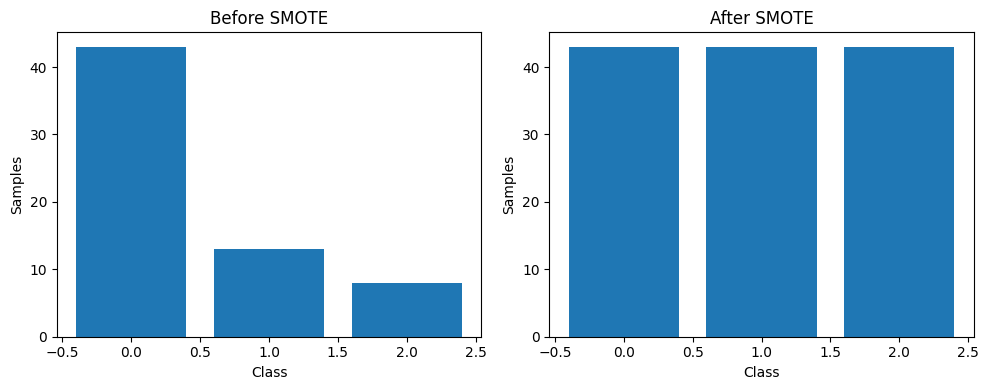

In [41]:

print("Class distribution BEFORE SMOTE:", Counter(y_train))
print("Class distribution AFTER SMOTE:", Counter(y_train_res))

import matplotlib.pyplot as plt

count_before = Counter(y_train)
count_after = Counter(y_train_res)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].bar(count_before.keys(), count_before.values())
axs[0].set_title("Before SMOTE")
axs[0].set_xlabel("Class")
axs[0].set_ylabel("Samples")

axs[1].bar(count_after.keys(), count_after.values())
axs[1].set_title("After SMOTE")
axs[1].set_xlabel("Class")
axs[1].set_ylabel("Samples")

plt.tight_layout()
plt.show()


#Models

##Logistic Regression Hypertuning + SMOTE

In this code, I begin by importing all the necessary libraries and preprocessing the data. I use StandardScaler to normalize the features, ensuring each one contributes equally to the model. Then, I split the dataset into training, validation, and test sets, while using stratification to preserve the class distribution across the splits in a 60, 20 and 20% respectively. Since the dataset is imbalanced, I apply SMOTE on the training set to synthetically generate more samples from the minority classes, which helps the models learn better representations. I then perform hyperparameter tuning on a logistic regression model using GridSearchCV, optimizing for the weighted F1 score to account for class imbalance. Once I find the best regularization parameter C, I use Sequential Backward Selection (SBS) to select the optimal subset of features by iteratively removing the least useful ones and keeping track of the accuracy. I plot the number of features against the validation accuracy to visualize performance. After identifying the best subset of features, I retrain the logistic regression model on this selection and evaluate it on the training, validation, and test sets. I also calculate training, validation, and test errors, as well as F1 scores for each. Finally, I run cross-validation to ensure the model generalizes well and report the mean and standard deviation of the CV accuracy.

Best Logistic Regression Parameters: {'C': 10}


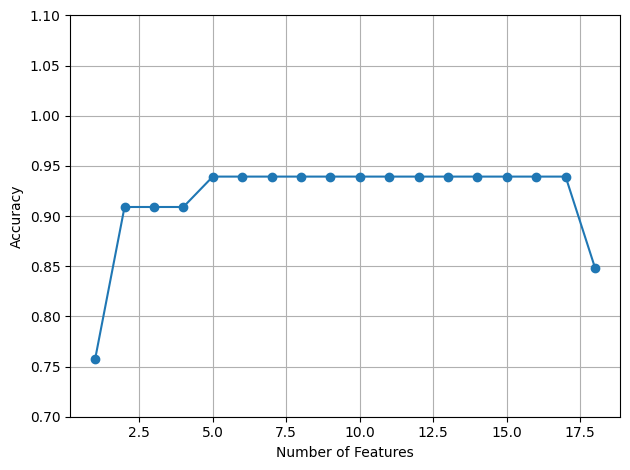

Best features: [0, 3, 5, 6, 8, 10, 11, 12, 15, 16]
Training Accuracy: 0.9535
Validation Accuracy: 0.7273
Test Accuracy: 0.8636
Train Error: 0.0465
Validation Error: 0.2727
Test Error: 0.1364
Cross-validation scores: [0.88461538 0.92307692 0.96153846 0.96153846 0.96      ]
Mean CV Accuracy: 0.9382
Standard Deviation of CV Accuracy: 0.0305
F1 Score (Train): 0.9535
F1 Score (Validation): 0.7159
F1 Score (Test): 0.8636


In [57]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=1, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp)

smote = SMOTE(random_state=1)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(LogisticRegression(random_state=1, max_iter=1000), param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid.fit(X_train_res, y_train_res)

best_log_reg = grid.best_estimator_
print("Best Logistic Regression Parameters:", grid.best_params_)

class SBS():
    def __init__(self, estimator, k_features, scoring=accuracy_score, test_size=0.25, random_state=1):
        self.scoring = scoring
        self.estimator = clone(estimator)
        self.k_features = k_features
        self.test_size = test_size
        self.random_state = random_state

    def fit(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state, stratify=y
        )
        dim = X_train.shape[1]
        self.indices_ = tuple(range(dim))
        self.subsets_ = [self.indices_]
        score = self._calc_score(X_train, y_train, X_test, y_test, self.indices_)
        self.scores_ = [score]

        while dim > self.k_features:
            scores = []
            subsets = []
            for p in combinations(self.indices_, r=dim - 1):
                score = self._calc_score(X_train, y_train, X_test, y_test, p)
                scores.append(score)
                subsets.append(p)

            best = np.argmax(scores)
            self.indices_ = subsets[best]
            self.subsets_.append(self.indices_)
            dim -= 1
            self.scores_.append(scores[best])
        self.k_score_ = self.scores_[-1]
        return self

    def transform(self, X):
        return X[:, self.indices_]

    def _calc_score(self, X_train, y_train, X_test, y_test, indices):
        self.estimator.fit(X_train[:, indices], y_train)
        y_pred = self.estimator.predict(X_test[:, indices])
        return self.scoring(y_test, y_pred)

sbs = SBS(best_log_reg, k_features=1)
sbs.fit(X_train_res, y_train_res)

k_feat = [len(k) for k in sbs.subsets_]
plt.plot(k_feat, sbs.scores_, marker='o')
plt.ylim([0.7, 1.1])
plt.ylabel('Accuracy')
plt.xlabel('Number of Features')
plt.grid()
plt.tight_layout()
plt.show()

k_best_features = list(sbs.subsets_[8])
print("Best features:", k_best_features)

best_log_reg.fit(X_train_res[:, k_best_features], y_train_res)

train_acc = best_log_reg.score(X_train_res[:, k_best_features], y_train_res)
val_acc = best_log_reg.score(X_val[:, k_best_features], y_val)
test_acc = best_log_reg.score(X_test[:, k_best_features], y_test)

train_error = 1 - train_acc
val_error = 1 - val_acc
test_error = 1 - test_acc

cv_scores = cross_val_score(best_log_reg, X_train_res[:, k_best_features], y_train_res, cv=5, scoring='accuracy')

f1_train = f1_score(y_train_res, best_log_reg.predict(X_train_res[:, k_best_features]), average='weighted')
f1_val = f1_score(y_val, best_log_reg.predict(X_val[:, k_best_features]), average='weighted')
f1_test = f1_score(y_test, best_log_reg.predict(X_test[:, k_best_features]), average='weighted')

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Train Error: {train_error:.4f}")
print(f"Validation Error: {val_error:.4f}")
print(f"Test Error: {test_error:.4f}")
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores.std():.4f}")
print(f"F1 Score (Train): {f1_train:.4f}")
print(f"F1 Score (Validation): {f1_val:.4f}")
print(f"F1 Score (Test): {f1_test:.4f}")


To enhance model interpretability and gain insight into feature contributions, I examined the coefficients of the trained logistic regression model. I first printed the class-wise coefficients for each of the selected features, which helps understand the direction and magnitude of each feature's influence on the model’s predictions. Positive coefficients increase the likelihood of a class, while negative values decrease it. To assess the overall importance of each feature across all classes, I computed the L2 norm of the coefficients, ranking the features accordingly. This allows us to identify which features most significantly impact the model. I also visualized the coefficients using a heatmap for easier interpretation, showing the varying contributions of each feature to the three classes. This analysis supports both transparency and a deeper understanding of the model's behavior.










=== Logistic Regression Coefficients by Class ===
                             Class 0   Class 1   Class 2
Contrast                    0.259011 -0.600919  0.341908
Homogeneity                -0.554891  1.796538 -1.241646
Std_Intensity              -0.093250  0.508607 -0.415357
Skew_Intensity             -0.161060 -0.987898  1.148957
Eccentricity               -1.729999 -2.642924  4.372923
radius of circle           -3.681547  0.461357  3.220190
background tissue_D         0.236390  1.691333 -1.927723
background tissue_F        -0.361246  1.354734 -0.993487
class of abnormality_ASYM  -0.647066  0.541419  0.105647
class of abnormality_CIRC  -1.304821  1.781779 -0.476958

=== Feature Importance Ranking (by L2 norm across classes) ===
Eccentricity                  5.394478
radius of circle              4.912867
background tissue_D           2.575384
class of abnormality_CIRC     2.259376
Homogeneity                   2.253251
background tissue_F           1.718377
Skew_Intensity          

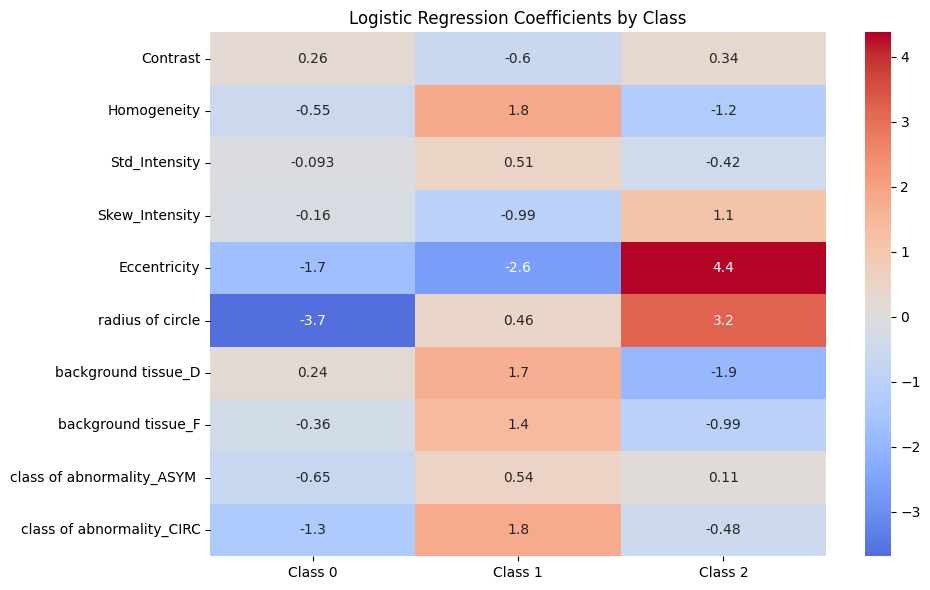

In [67]:
import pandas as pd
import seaborn as sns

print("\n=== Logistic Regression Coefficients by Class ===")
coef_df = pd.DataFrame(best_log_reg.coef_.T,
                       index=[X.columns[i] for i in k_best_features],
                       columns=[f"Class {i}" for i in range(best_log_reg.coef_.shape[0])])
print(coef_df)

importance_scores = np.linalg.norm(best_log_reg.coef_, axis=0)
importance_ranking = pd.Series(importance_scores, index=[X.columns[i] for i in k_best_features])
importance_ranking = importance_ranking.sort_values(ascending=False)
print("\n=== Feature Importance Ranking (by L2 norm across classes) ===")
print(importance_ranking)

plt.figure(figsize=(10, 6))
sns.heatmap(coef_df, annot=True, cmap="coolwarm", center=0)
plt.title("Logistic Regression Coefficients by Class")
plt.tight_layout()
plt.show()


In multiclass logistic regression, each class is associated with its own set of coefficients, where a positive coefficient means that an increase in the feature value raises the likelihood of that class, and a negative one lowers it. The larger the magnitude of the coefficient, the greater the feature's influence. Interpreting the coefficients, we find that features like eccentricity show a strong positive influence for malignant cases and strong negative influence for normal and benign ones, suggesting it is a key indicator of malignancy. Similarly, the radius of the circle is negatively associated with normal cases and positively with malignant ones, indicating that larger radii are more common in malignancies. Homogeneity is positively linked with benign cases but negatively with malignant ones, reflecting that homogeneous textures may imply benign abnormalities. Skew_Intensity also suggests malignancy when high, as it shows a positive coefficient for Class 2. Categorical variables like background tissue type and abnormality class contribute differently across classes, for instance, background tissue_D may help distinguish between benign and malignant, and class of abnormality_CIRC is more associated with benign cases, showing how specific patterns help the model differentiate classes.









## Support Vector Machine

In this code, a support vector machine (SVM) classifier is implemented for a multiclass classification problem using extracted image features. First, the dataset is scaled using StandardScaler and split into training, validation, and test sets with stratification to preserve class proportions. Since the dataset is imbalanced, SMOTE is applied to the training set to balance the classes. A grid search with cross-validation is then used to identify the best value for the SVM's regularization parameter C. After identifying the best model, a custom Sequential Backward Selection (SBS) algorithm is used to iteratively reduce the number of features by evaluating model accuracy, selecting the optimal subset of features. The classifier is then retrained using only these selected features. Model performance is evaluated on training, validation, and test sets using accuracy, F1 score, and error rate, and cross-validation is also performed to assess generalization. The code outputs all these metrics, helping to validate the effectiveness of the SVM model and the selected feature subset.

Train class distribution BEFORE SMOTE: Counter({0: 43, 1: 13, 2: 8})
Train class distribution AFTER SMOTE: Counter({0: 43, 1: 43, 2: 43})
Best SVM Parameters: {'C': 10}


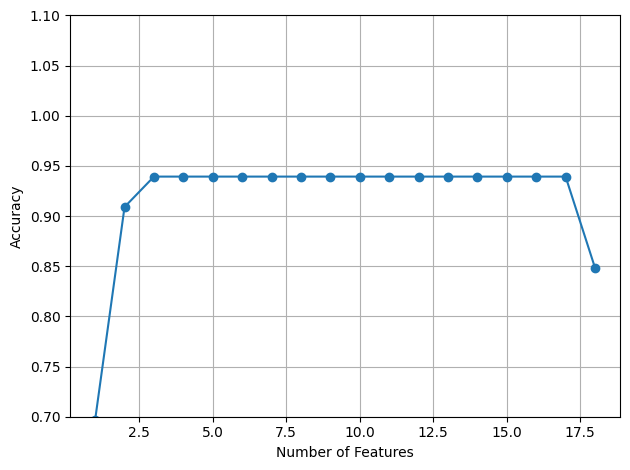

Best features: [0, 2, 3, 4, 5, 6, 7, 8, 10, 12]
Training Accuracy: 1.0000
Validation Accuracy: 0.7273
Test Accuracy: 0.8182
Train Error: 0.0000
Validation Error: 0.2727
Test Error: 0.1818
F1 Score (Train): 1.0000
F1 Score (Validation): 0.6847
F1 Score (Test): 0.7756
Cross-validation accuracy scores: [1.   1.   1.   1.   0.88]
Mean CV Accuracy: 0.9760
Standard Deviation of CV Accuracy: 0.0480


In [56]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=1, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)


print("Train class distribution BEFORE SMOTE:", Counter(y_train))
smote = SMOTE(random_state=1)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Train class distribution AFTER SMOTE:", Counter(y_train_res))


param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(SVC(kernel='rbf', random_state=1), param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid.fit(X_train_res, y_train_res)

best_svm = grid.best_estimator_
print("Best SVM Parameters:", grid.best_params_)


class SBS():
    def __init__(self, estimator, k_features, scoring=accuracy_score, test_size=0.25, random_state=1):
        self.scoring = scoring
        self.estimator = clone(estimator)
        self.k_features = k_features
        self.test_size = test_size
        self.random_state = random_state

    def fit(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state, stratify=y
        )
        dim = X_train.shape[1]
        self.indices_ = tuple(range(dim))
        self.subsets_ = [self.indices_]
        score = self._calc_score(X_train, y_train, X_test, y_test, self.indices_)
        self.scores_ = [score]

        while dim > self.k_features:
            scores = []
            subsets = []
            for p in combinations(self.indices_, r=dim - 1):
                score = self._calc_score(X_train, y_train, X_test, y_test, p)
                scores.append(score)
                subsets.append(p)

            best = np.argmax(scores)
            self.indices_ = subsets[best]
            self.subsets_.append(self.indices_)
            dim -= 1
            self.scores_.append(scores[best])

        self.k_score_ = self.scores_[-1]
        return self

    def transform(self, X):
        return X[:, self.indices_]

    def _calc_score(self, X_train, y_train, X_test, y_test, indices):
        self.estimator.fit(X_train[:, indices], y_train)
        y_pred = self.estimator.predict(X_test[:, indices])
        return self.scoring(y_test, y_pred)


sbs = SBS(best_svm, k_features=1)
sbs.fit(X_train_res, y_train_res)


k_feat = [len(k) for k in sbs.subsets_]
plt.plot(k_feat, sbs.scores_, marker='o')
plt.ylim([0.7, 1.1])
plt.ylabel('Accuracy')
plt.xlabel('Number of Features')
plt.grid()
plt.tight_layout()
plt.show()


k_best_features = list(sbs.subsets_[8])
print("Best features:", k_best_features)

best_svm.fit(X_train_res[:, k_best_features], y_train_res)
y_train_pred = best_svm.predict(X_train_res[:, k_best_features])
y_val_pred = best_svm.predict(X_val[:, k_best_features])
y_test_pred = best_svm.predict(X_test[:, k_best_features])

train_accuracy = accuracy_score(y_train_res, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

f1_train = f1_score(y_train_res, y_train_pred, average='weighted')
f1_val = f1_score(y_val, y_val_pred, average='weighted')
f1_test = f1_score(y_test, y_test_pred, average='weighted')

train_error = 1 - train_accuracy
val_error = 1 - val_accuracy
test_error = 1 - test_accuracy

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
cv_scores = cross_val_score(best_svm, X_train_res[:, k_best_features], y_train_res, cv=cv, scoring='accuracy')
cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Train Error: {train_error:.4f}")
print(f"Validation Error: {val_error:.4f}")
print(f"Test Error: {test_error:.4f}")
print(f"F1 Score (Train): {f1_train:.4f}")
print(f"F1 Score (Validation): {f1_val:.4f}")
print(f"F1 Score (Test): {f1_test:.4f}")
print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_mean:.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_std:.4f}")


##Random Forest

In this code, a Random Forest classifier is trained and evaluated on a dataset that has been preprocessed and balanced to address class imbalance. First, the features are standardized using StandardScaler, and the data is split into training, validation, and test sets using stratified sampling to preserve class distribution. SMOTE is applied to the training data to synthetically oversample the minority classes and improve model fairness. A grid search with 5-fold stratified cross-validation is used to find the best hyperparameters for the Random Forest model, tuning the number of trees, maximum depth, and minimum samples required to split a node. After training the optimized model, the code visualizes feature importances to understand which features most influence the predictions. The trained model is then evaluated on training, validation, and test sets using accuracy and weighted F1 score. Cross-validation is also performed on the resampled training set to assess generalization. Finally, the top 10 most important features are printed, providing further insight into the model's decision-making process.

Class distribution BEFORE SMOTE: Counter({0: 43, 1: 13, 2: 8})
Class distribution AFTER SMOTE: Counter({0: 43, 1: 43, 2: 43})

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


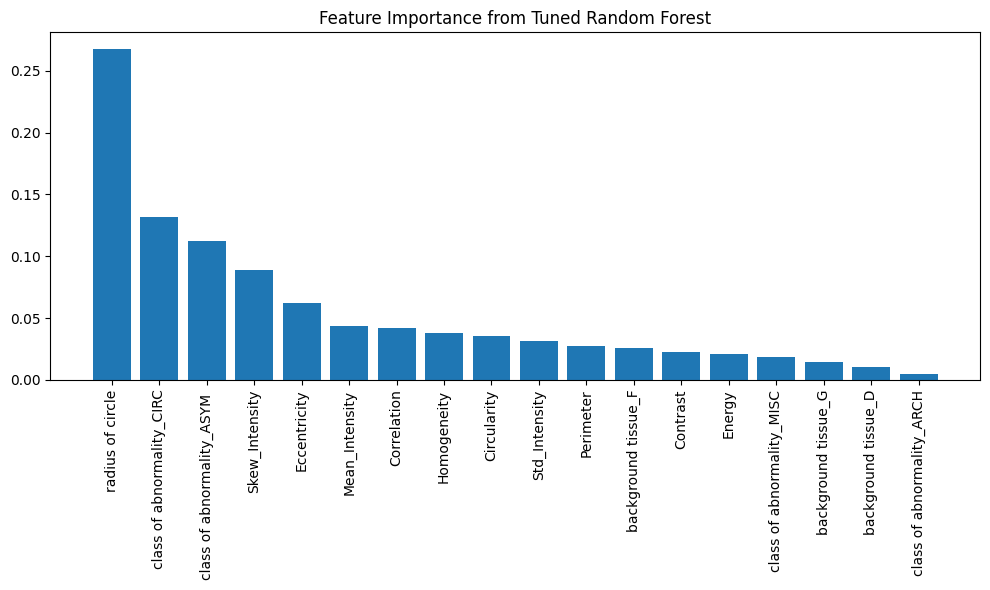


=== Tuned Random Forest Results ===
Training Accuracy:       1.0000
Validation Accuracy:     0.9091
Test Accuracy:           0.8636
Training Error:          0.0000
Validation Error:        0.0909
Test Error:              0.1364
F1 Score (Train):        1.0000
F1 Score (Validation):   0.8955
F1 Score (Test):         0.8507
Cross-validation Scores: [0.96153846 1.         1.         1.         0.84      ]
Mean CV Accuracy:        0.9603
CV Accuracy Std Dev:     0.0620

Top 10 Most Important Features:
1. radius of circle: 0.2679
2. class of abnormality_CIRC: 0.1320
3. class of abnormality_ASYM : 0.1127
4. Skew_Intensity: 0.0891
5. Eccentricity: 0.0619
6. Mean_Intensity: 0.0438
7. Correlation: 0.0421
8. Homogeneity: 0.0381
9. Circularity: 0.0354
10. Std_Intensity: 0.0314


In [53]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=1, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp)

print("Class distribution BEFORE SMOTE:", Counter(y_train))
smote = SMOTE(random_state=1)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Class distribution AFTER SMOTE:", Counter(y_train_res))

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
grid_search = GridSearchCV(rf, param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train_res, y_train_res)

best_rf = grid_search.best_estimator_
print("\nBest Random Forest Parameters:")
print(grid_search.best_params_)

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns if hasattr(X, 'columns') else [f"Feature {i}" for i in range(X.shape[1])]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance from Tuned Random Forest")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
plt.tight_layout()
plt.show()

y_train_pred = best_rf.predict(X_train_res)
y_val_pred = best_rf.predict(X_val)
y_test_pred = best_rf.predict(X_test)

train_accuracy_rf = accuracy_score(y_train_res, y_train_pred)
val_accuracy_rf = accuracy_score(y_val, y_val_pred)
test_accuracy_rf = accuracy_score(y_test, y_test_pred)

f1_train_rf = f1_score(y_train_res, y_train_pred, average='weighted')
f1_val_rf = f1_score(y_val, y_val_pred, average='weighted')
f1_test_rf = f1_score(y_test, y_test_pred, average='weighted')

cv_scores_rf = cross_val_score(best_rf, X_train_res, y_train_res, cv=cv, scoring='accuracy')

print("\n=== Tuned Random Forest Results ===")
print(f"Training Accuracy:       {train_accuracy_rf:.4f}")
print(f"Validation Accuracy:     {val_accuracy_rf:.4f}")
print(f"Test Accuracy:           {test_accuracy_rf:.4f}")
print(f"Training Error:          {1 - train_accuracy_rf:.4f}")
print(f"Validation Error:        {1 - val_accuracy_rf:.4f}")
print(f"Test Error:              {1 - test_accuracy_rf:.4f}")
print(f"F1 Score (Train):        {f1_train_rf:.4f}")
print(f"F1 Score (Validation):   {f1_val_rf:.4f}")
print(f"F1 Score (Test):         {f1_test_rf:.4f}")
print(f"Cross-validation Scores: {cv_scores_rf}")
print(f"Mean CV Accuracy:        {cv_scores_rf.mean():.4f}")
print(f"CV Accuracy Std Dev:     {cv_scores_rf.std():.4f}")

print("\nTop 10 Most Important Features:")
for i in range(min(10, len(importances))):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")


This code visualizes how a small Random Forest classifier, built using only the two most important features, partitions the feature space for classification. It begins by selecting the top two features (based on feature importance ranking stored in indices) and creates a 2D version of the dataset using only these features for visualization. Then, the data is split into training and test sets while preserving class distribution using stratified sampling.

A small Random Forest model with only 5 decision trees is initialized using the best hyperparameters found previously (max_depth and min_samples_split). The model is trained on the 2D training data, and each individual decision tree's decision boundary is plotted in separate subplots using mglearn. These plots show how each tree splits the feature space based on the top two features.

Finally, the last subplot shows the overall ensemble decision boundary of the entire Random Forest, which combines the individual trees’ decisions into a smoother, more generalized classification surface. Labels for the axes are set according to the names of the top two features to make the plots interpretable. This visualization helps to understand how Random Forest models aggregate decision boundaries and why they are more robust than individual trees.

In [ ]:
pip install mglearn

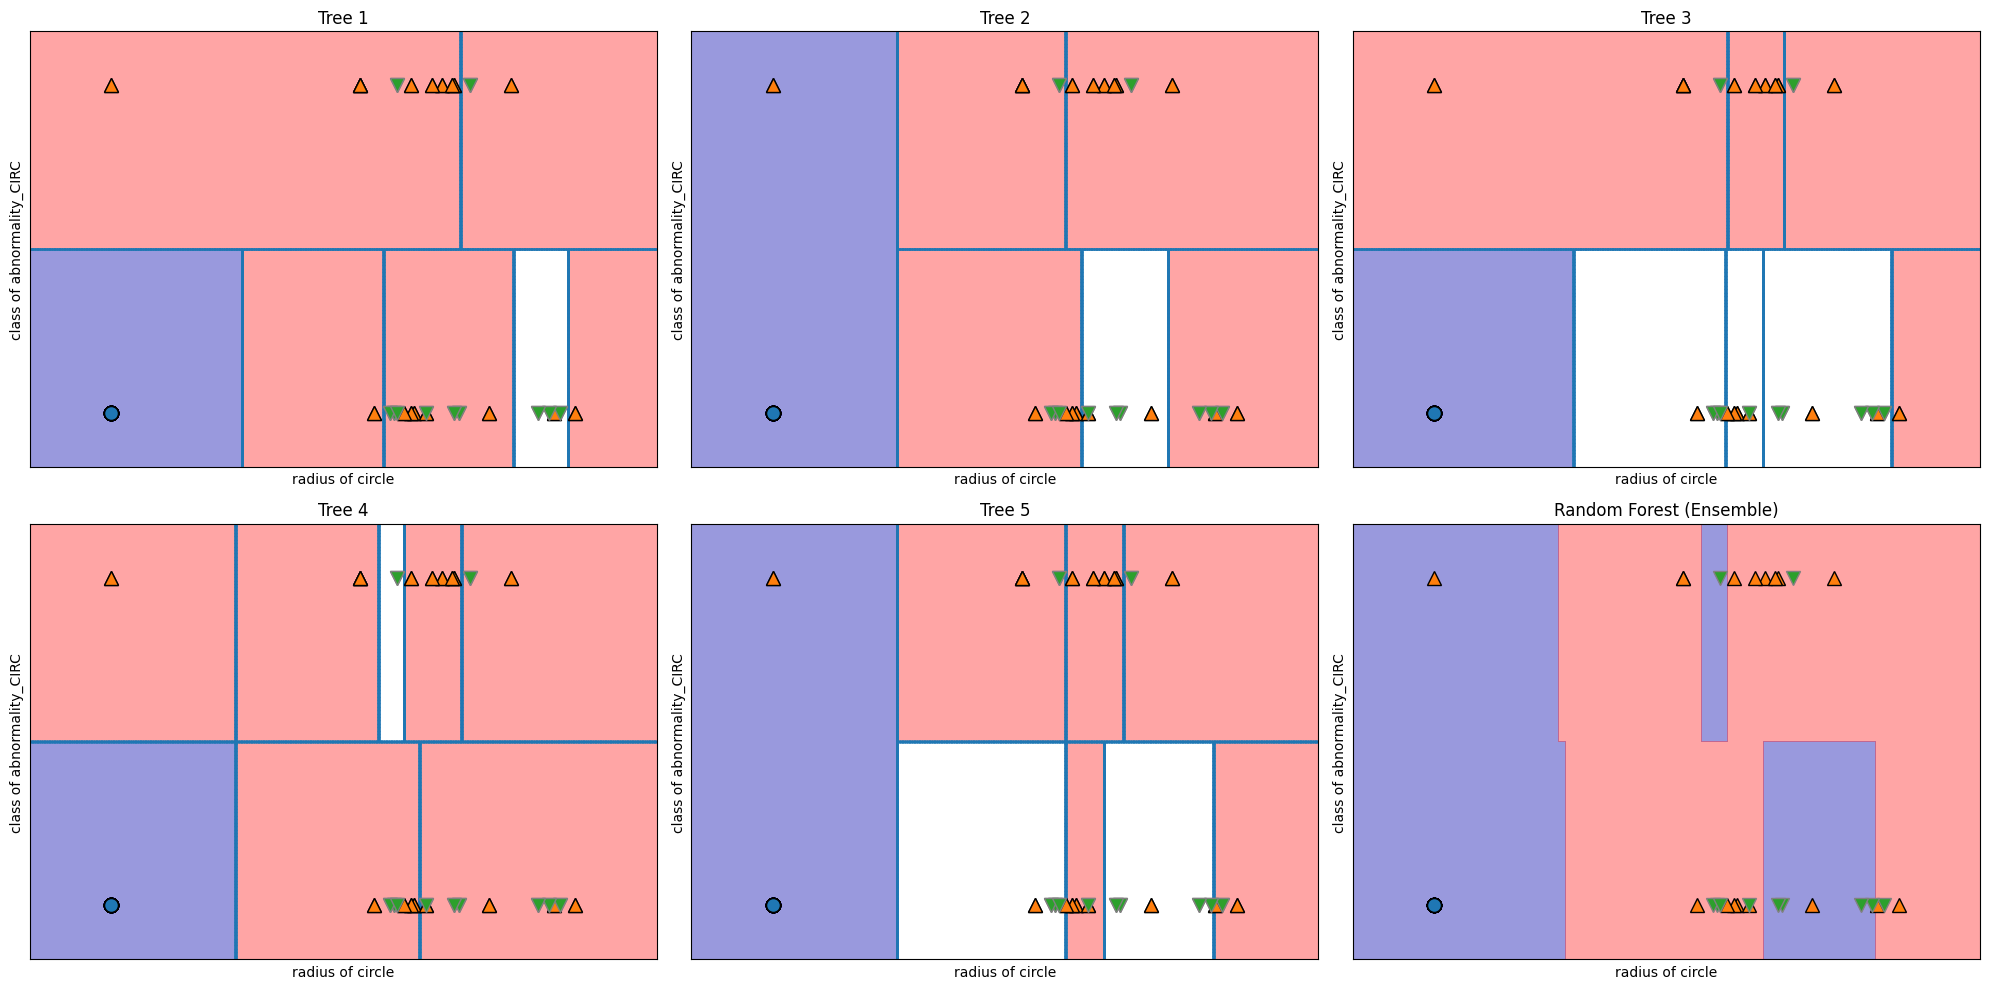

In [54]:
import mglearn
import matplotlib.pyplot as plt

top2_idx = indices[:2]
X_vis = X_scaled[:, top2_idx]
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y, stratify=y, test_size=0.2, random_state=1)

forest_vis = RandomForestClassifier(
    n_estimators=5,
    max_depth=grid_search.best_params_['max_depth'],
    min_samples_split=grid_search.best_params_['min_samples_split'],
    random_state=1
)
forest_vis.fit(X_train_vis, y_train_vis)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for i, (ax, tree_model) in enumerate(zip(axes.ravel()[:-1], forest_vis.estimators_)):
    ax.set_title(f"Tree {i+1}")
    mglearn.plots.plot_tree_partition(X_train_vis, y_train_vis, tree_model, ax=ax)
    mglearn.discrete_scatter(X_train_vis[:, 0], X_train_vis[:, 1], y_train_vis, ax=ax)

ax = axes.ravel()[-1]
ax.set_title("Random Forest (Ensemble)")
mglearn.plots.plot_2d_separator(forest_vis, X_train_vis, fill=True, alpha=0.4, ax=ax)
mglearn.discrete_scatter(X_train_vis[:, 0], X_train_vis[:, 1], y_train_vis, ax=ax)

for ax in axes.ravel():
    ax.set_xlabel(feature_names[top2_idx[0]])
    ax.set_ylabel(feature_names[top2_idx[1]])

plt.tight_layout()
plt.show()


This code generates a detailed visualization of a single decision tree from the previously trained and tuned Random Forest model. It selects the first tree in the ensemble (best_rf.estimators_[0]) and uses sklearn.tree.plot_tree() to render it.

The resulting plot displays the full structure of the tree, including the feature and threshold used at each split, the predicted class at each leaf, and the distribution of samples per node. This helps to interpret how a single tree in the ensemble makes decisions, providing insight into the logic used within the Random Forest without the complexity of the full ensemble.

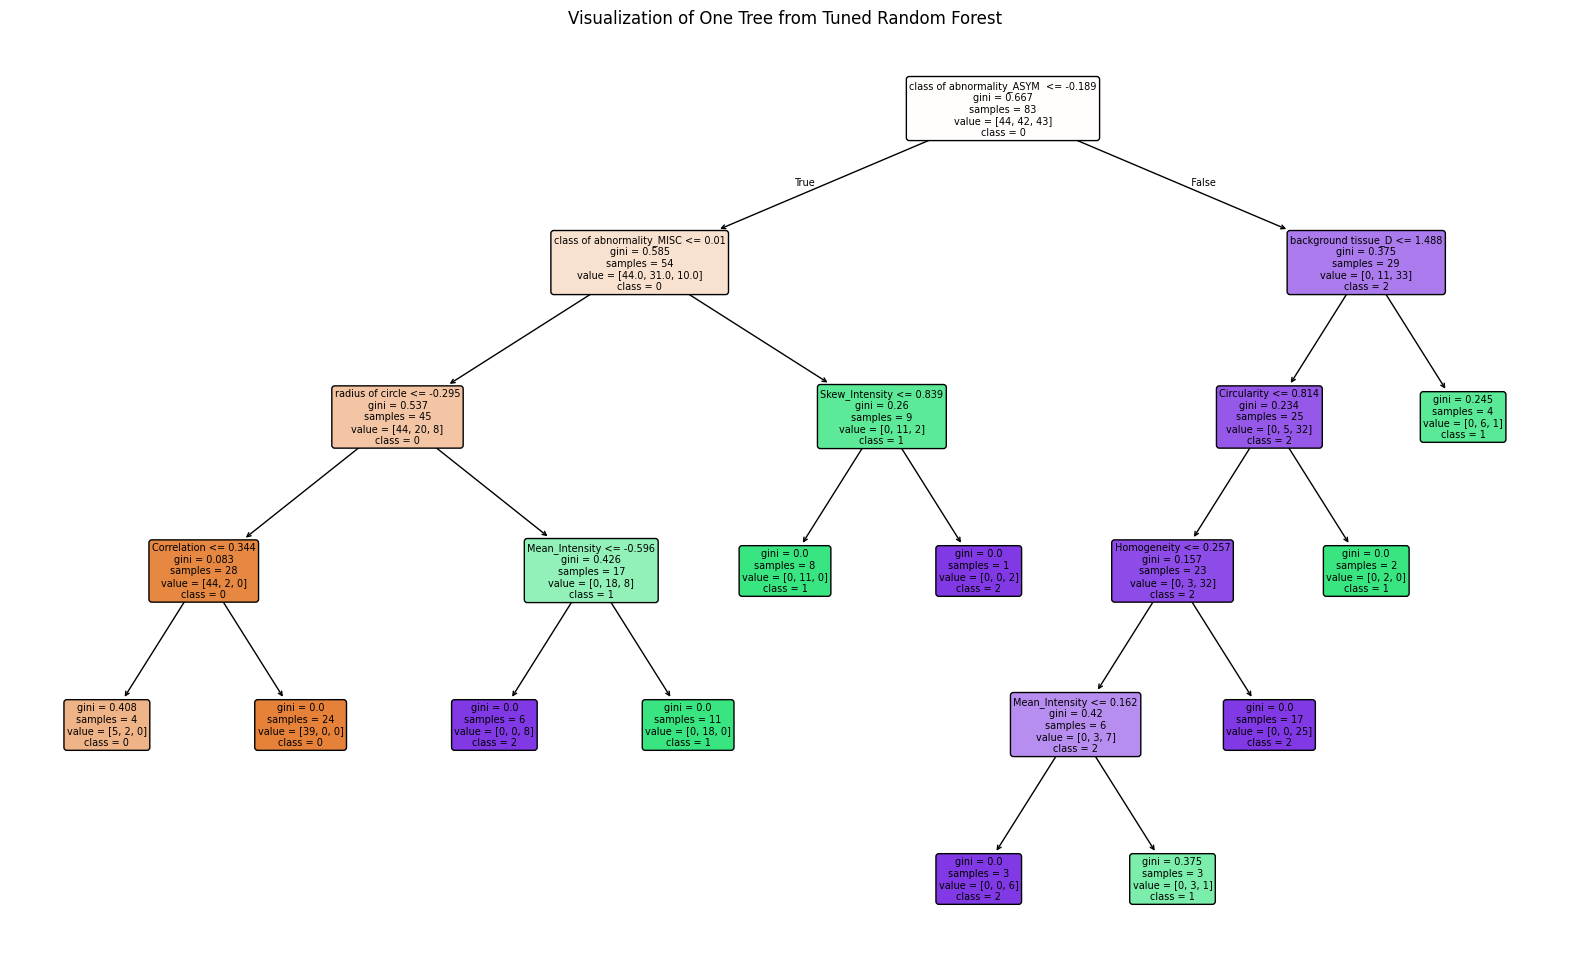

In [55]:
from sklearn import tree

one_tree = best_rf.estimators_[0]

plt.figure(figsize=(20, 12))
tree.plot_tree(one_tree,
               feature_names=feature_names,
               class_names=[str(cls) for cls in np.unique(y)],
               filled=True,
               rounded=True)
plt.title("Visualization of One Tree from Tuned Random Forest")
plt.show()


##Neural Networks

This code performs hyperparameter tuning and visualization of a neural network (MLPClassifier) applied to a reduced 2D feature space using PCA. First, the data is standardized and split into training, validation, and test sets with stratified sampling to preserve class distribution. SMOTE is applied to the training data to balance the classes. PCA is then used to project the data onto its first two principal components to enable 2D visualization. A grid search is conducted over combinations of learning rates and hidden layer architectures, and for each configuration, an MLP is trained and validated, while the decision boundaries are plotted using mglearn. The best configuration based on validation accuracy is stored. The best model is retrained on the combined training and validation set, and evaluated on all sets using accuracy, F1 score, and cross-validation metrics. The loss curve of the final model is plotted to show convergence behavior. Finally, a decision boundary of the best model in 2D PCA space is visualized, showing how the model separates the classes after training. This approach helps interpret model behavior and tuning effects even when the original feature space is high-dimensional.

Class distribution BEFORE SMOTE: Counter({0: 43, 1: 13, 2: 8})
Class distribution AFTER SMOTE: Counter({0: 43, 1: 43, 2: 43})
New Best Score: 0.5454545454545454
Best Params: {'hidden_layer_sizes': (10,), 'learning_rate': 0.001}
New Best Score: 0.6363636363636364
Best Params: {'hidden_layer_sizes': (50,), 'learning_rate': 0.01}
New Best Score: 0.6818181818181818
Best Params: {'hidden_layer_sizes': (100,), 'learning_rate': 0.1}


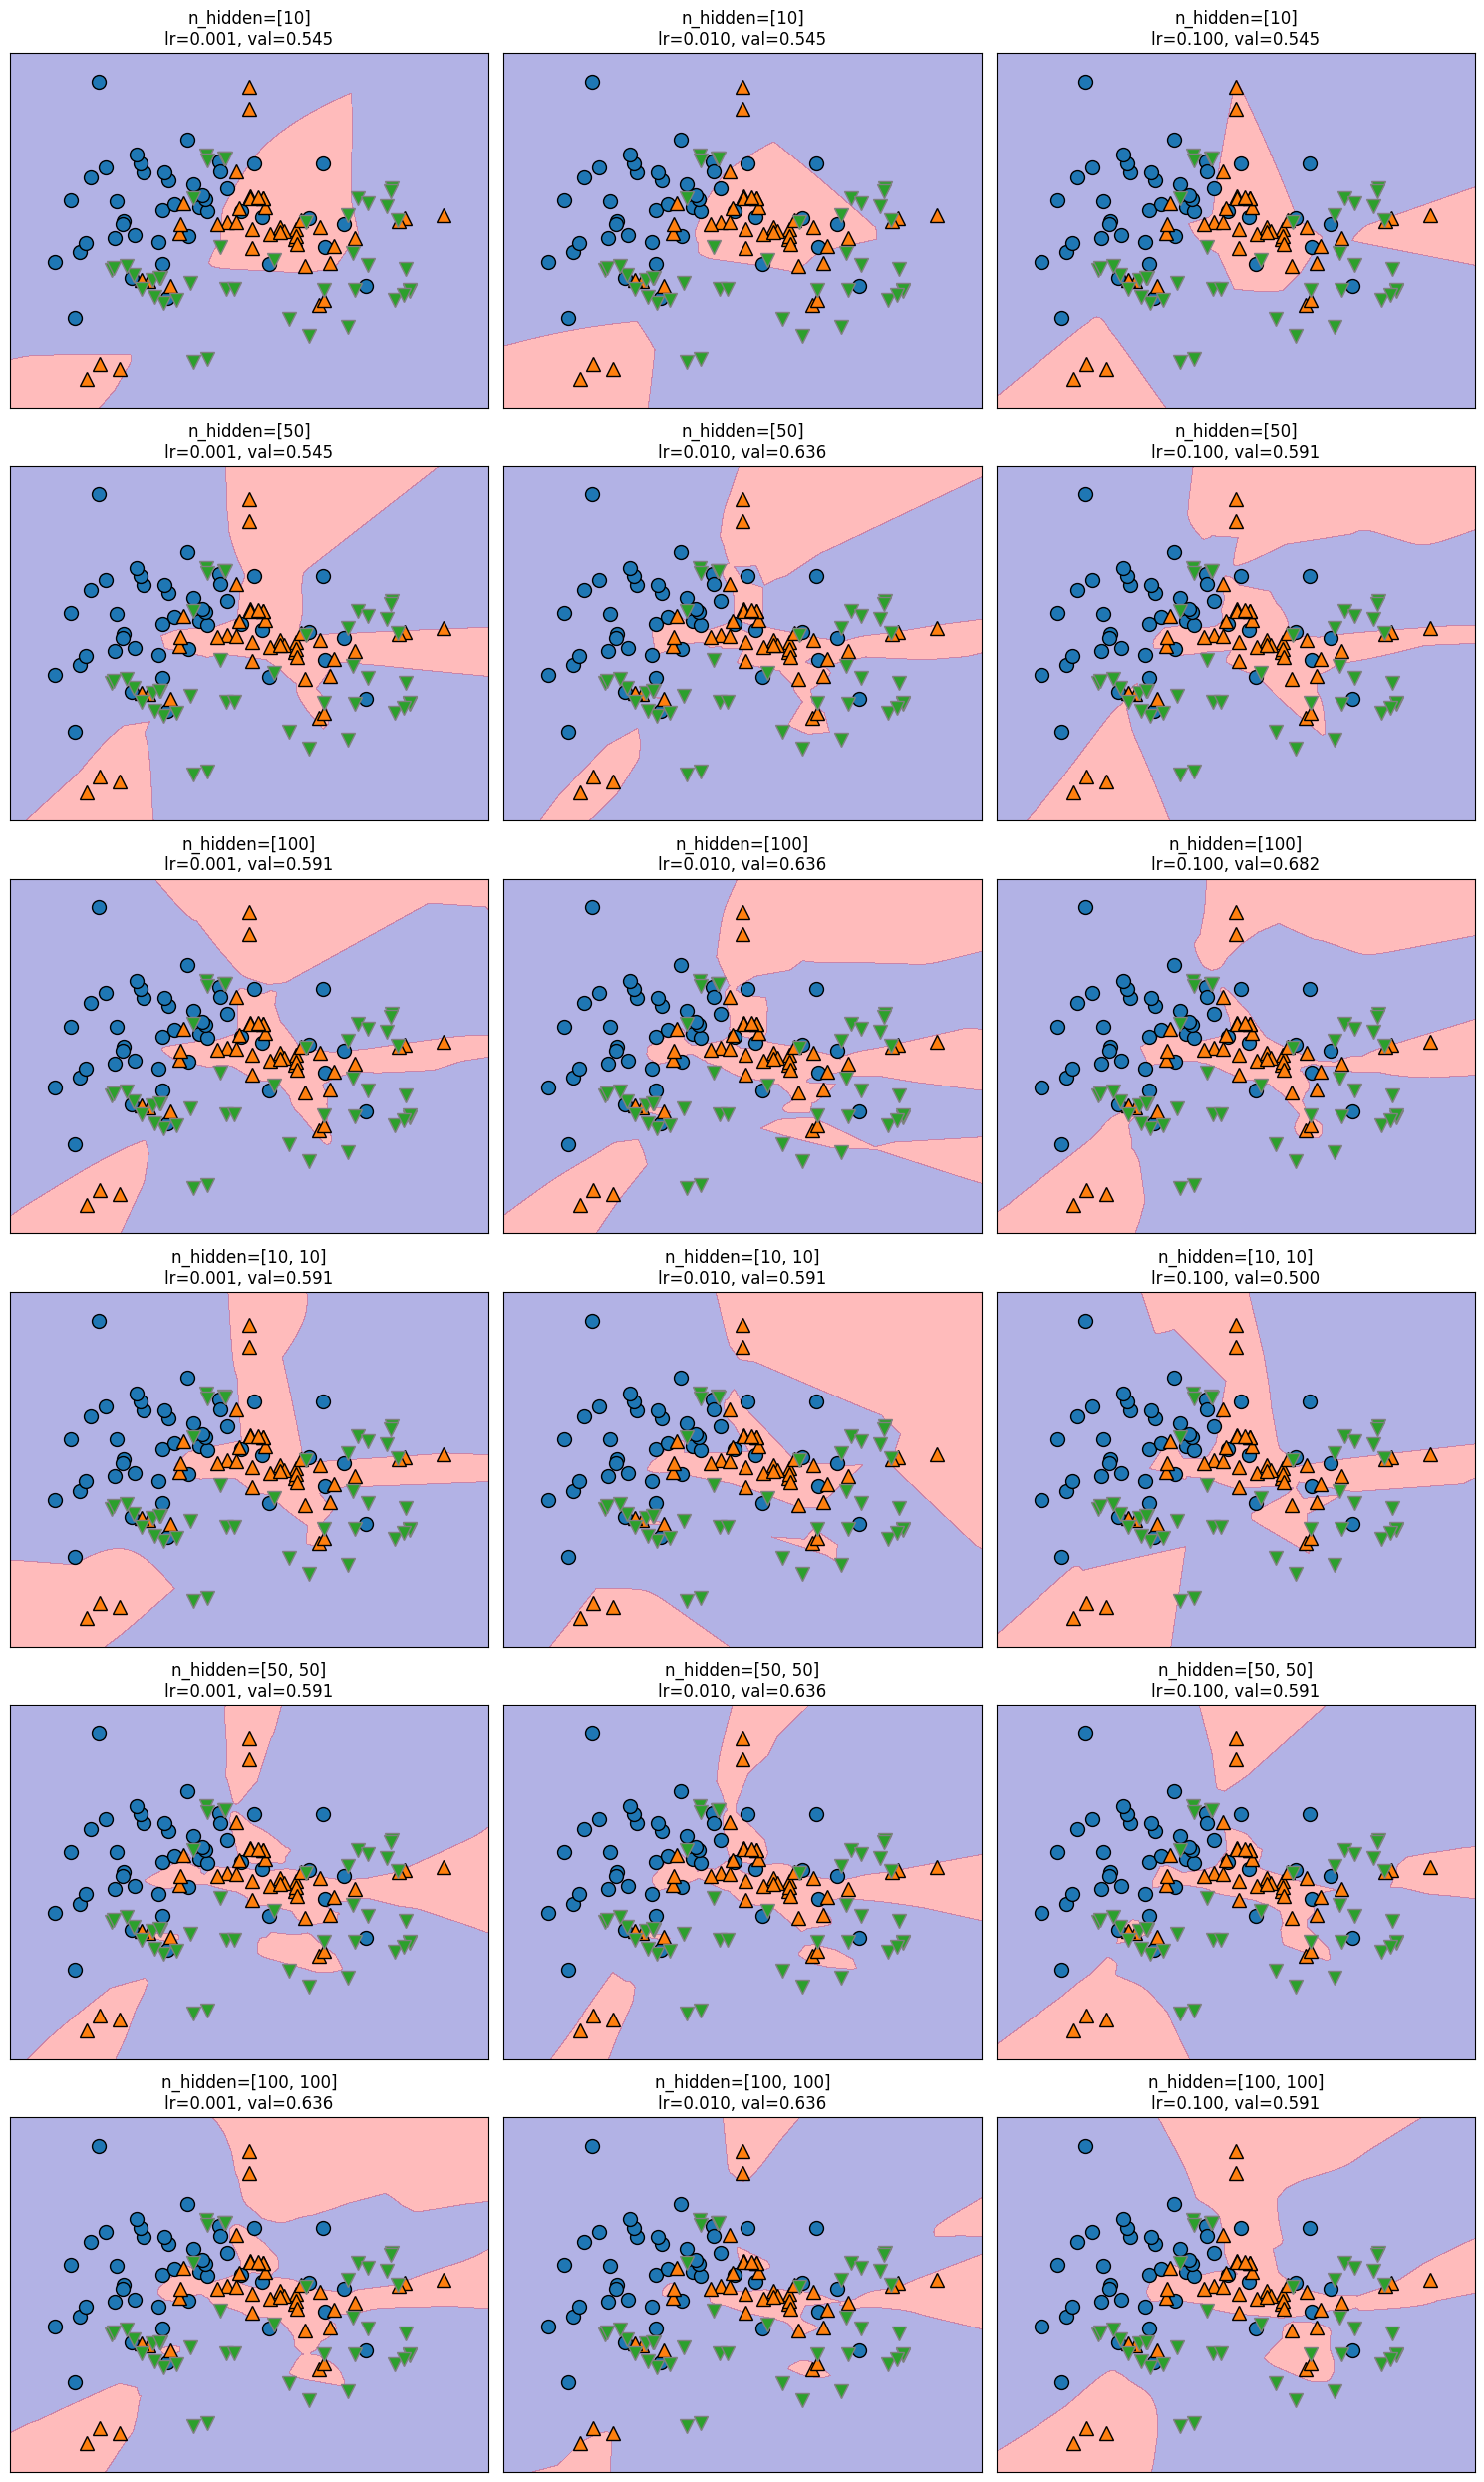


 Final Model Evaluation
Hidden layers: (100,)
Learning rate: 0.1
Train Accuracy: 1.0000
Validation Accuracy: 1.0000
Test Accuracy: 0.9091
Train Error: 0.0000
Validation Error: 0.0000
Test Error: 0.0909
F1 Score (Train): 1.0000
F1 Score (Validation): 1.0000
F1 Score (Test): 0.9091
Cross-validation Accuracy Scores: [1.         0.93333333 0.93333333 0.9        0.83333333]
Mean CV Accuracy: 0.9200
Standard Deviation of CV Accuracy: 0.0542


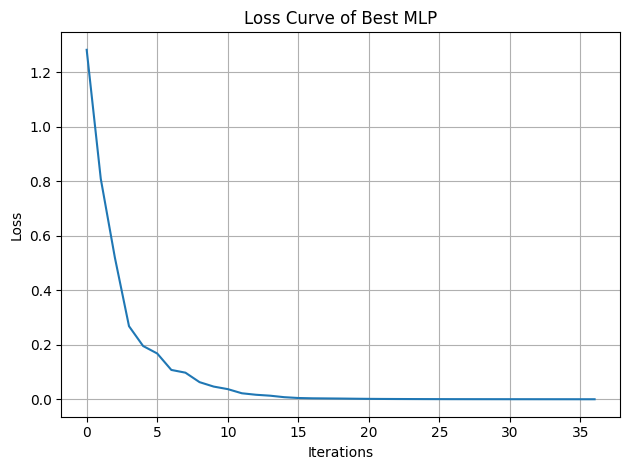

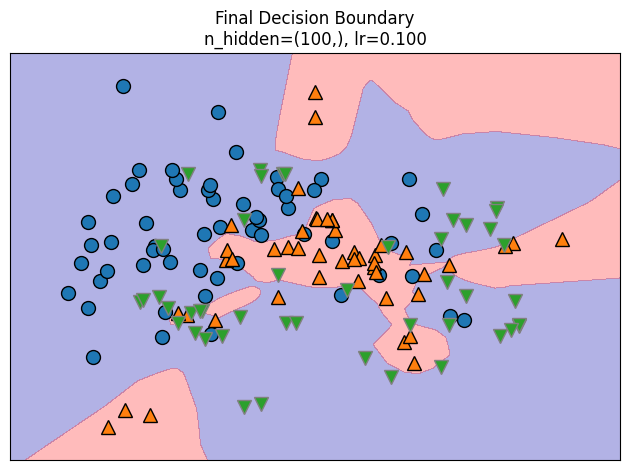

In [52]:

from sklearn.neural_network import MLPClassifier
from collections import Counter
from sklearn.decomposition import PCA


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_temp, X_test, y_temp, y_test = train_test_split(X_scaled[:, k_best_features_rf], y, test_size=0.2, stratify=y, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=1)

print("Class distribution BEFORE SMOTE:", Counter(y_train))
smote = SMOTE(random_state=1)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Class distribution AFTER SMOTE:", Counter(y_train_res))

pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_res)
X_val_2d = pca.transform(X_val)

learning_rates = [0.001, 0.01, 0.1]
hidden_layer_sizes = [(10,), (50,), (100,), (10, 10), (50, 50), (100, 100)]
best_score = 0
best_params = {}

fig, axes = plt.subplots(6, 3, figsize=(15, 25))
axes = axes.ravel()
plot_idx = 0

for hls in hidden_layer_sizes:
    for lr in learning_rates:
        mlp = MLPClassifier(
            solver='adam',
            random_state=0,
            hidden_layer_sizes=hls,
            learning_rate_init=lr,
            max_iter=5000
        )
        mlp.fit(X_train_2d, y_train_res)
        val_score = mlp.score(X_val_2d, y_val)

        ax = axes[plot_idx]
        mglearn.plots.plot_2d_separator(mlp, X_train_2d, fill=True, alpha=0.3, ax=ax)
        mglearn.discrete_scatter(X_train_2d[:, 0], X_train_2d[:, 1], y_train_res, ax=ax)

        if len(hls) > 1:
            ax.set_title(f"n_hidden=[{hls[0]}, {hls[1]}]\nlr={lr:.3f}, val={val_score:.3f}")
        else:
            ax.set_title(f"n_hidden=[{hls[0]}]\nlr={lr:.3f}, val={val_score:.3f}")

        if val_score > best_score:
            best_score = val_score
            best_params = {'hidden_layer_sizes': hls, 'learning_rate': lr}
            print("New Best Score:", best_score)
            print("Best Params:", best_params)

        plot_idx += 1

plt.tight_layout()
plt.show()

X_train_val = np.vstack([X_train_res, X_val])
y_train_val = np.hstack([y_train_res, y_val])

best_mlp = MLPClassifier(
    solver='adam',
    random_state=0,
    hidden_layer_sizes=best_params['hidden_layer_sizes'],
    learning_rate_init=best_params['learning_rate'],
    max_iter=5000
)
best_mlp.fit(X_train_val, y_train_val)

train_pred = best_mlp.predict(X_train_val)
val_pred = best_mlp.predict(X_val)
test_pred = best_mlp.predict(X_test)

train_acc = accuracy_score(y_train_val, train_pred)
val_acc = accuracy_score(y_val, val_pred)
test_acc = accuracy_score(y_test, test_pred)

train_error = 1 - train_acc
val_error = 1 - val_acc
test_error = 1 - test_acc

f1_train = f1_score(y_train_val, train_pred, average='weighted')
f1_val = f1_score(y_val, val_pred, average='weighted')
f1_test = f1_score(y_test, test_pred, average='weighted')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
cv_scores = cross_val_score(best_mlp, X_train_val, y_train_val, cv=cv, scoring='accuracy')
cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print("\n Final Model Evaluation")
print(f"Hidden layers: {best_params['hidden_layer_sizes']}")
print(f"Learning rate: {best_params['learning_rate']}")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Train Error: {train_error:.4f}")
print(f"Validation Error: {val_error:.4f}")
print(f"Test Error: {test_error:.4f}")
print(f"F1 Score (Train): {f1_train:.4f}")
print(f"F1 Score (Validation): {f1_val:.4f}")
print(f"F1 Score (Test): {f1_test:.4f}")
print(f"Cross-validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_mean:.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_std:.4f}")

plt.figure()
plt.plot(best_mlp.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Curve of Best MLP")
plt.grid(True)
plt.tight_layout()
plt.show()

mlp_final = MLPClassifier(
    solver='adam',
    random_state=0,
    hidden_layer_sizes=best_params['hidden_layer_sizes'],
    learning_rate_init=best_params['learning_rate'],
    max_iter=5000
)
mlp_final.fit(pca.transform(X_train_val), y_train_val)

fig, ax = plt.subplots()
mglearn.plots.plot_2d_separator(mlp_final, pca.transform(X_train_val), fill=True, alpha=0.3, ax=ax)
mglearn.discrete_scatter(pca.transform(X_train_val)[:, 0], pca.transform(X_train_val)[:, 1], y_train_val, ax=ax)
ax.set_title(f"Final Decision Boundary\nn_hidden={best_params['hidden_layer_sizes']}, lr={best_params['learning_rate']:.3f}")
plt.tight_layout()
plt.show()


#Results and Discussion

This four tables summarizes the results from the four models.

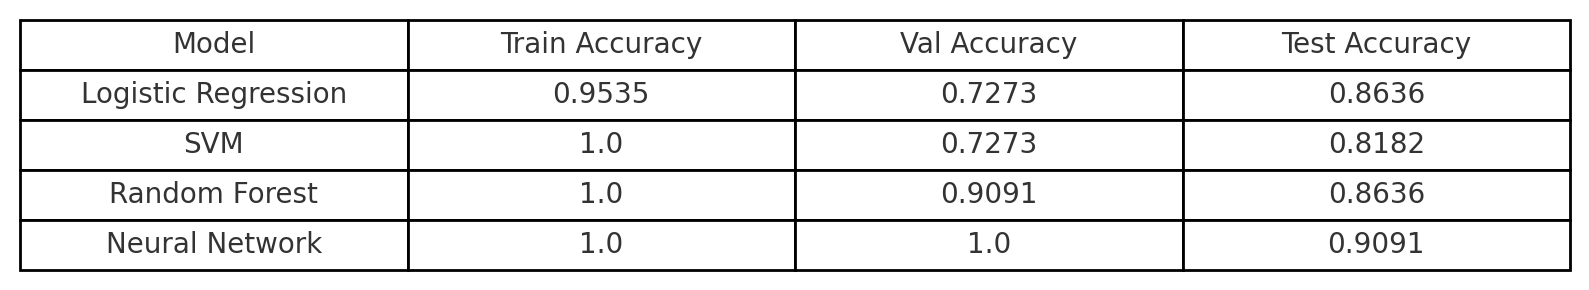

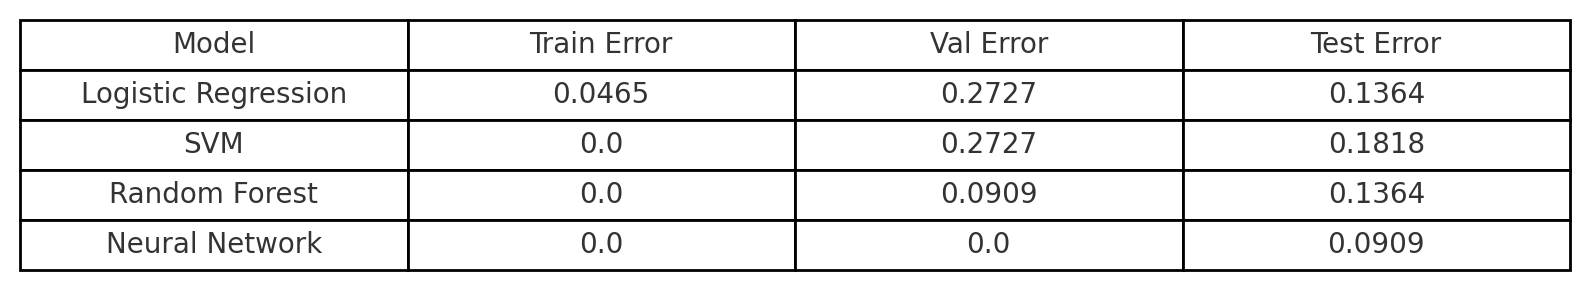

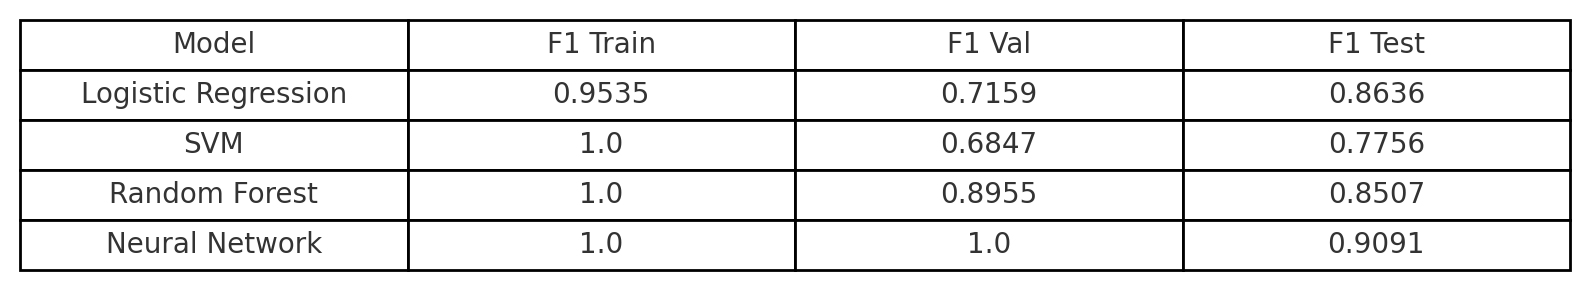

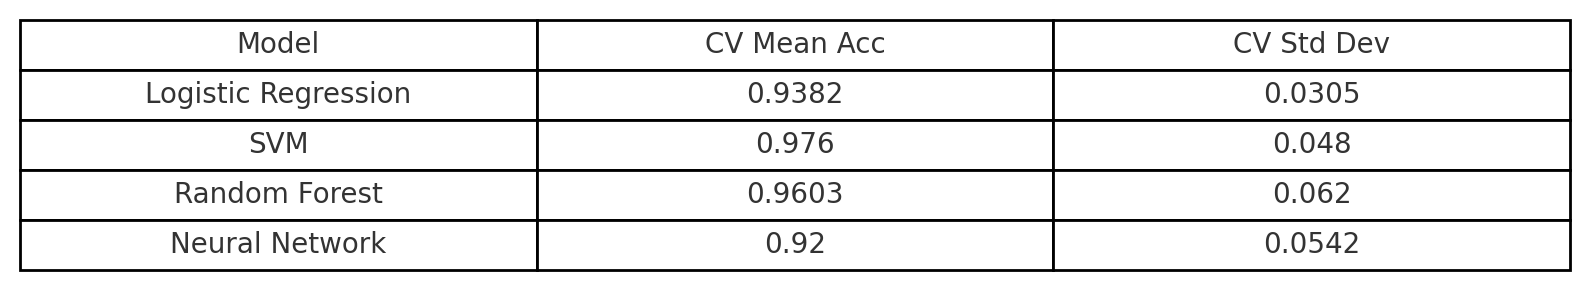

Based on the results obtained from all models, the Neural Network
 and Support Vector Machine appear to be the top performing classi
f
 iers. The Neural Network achieved perfect training and validation
 scores and a high test accuracy (0.9091) and F1 score (0.9091), in
dicating it was able to generalize well while capturing nonlinear
 patterns in the data. However, its perfect training score also sug
gests a potential risk of overfitting that should be monitored. The
 Support Vector Machine also showed strong performance with
 a test accuracy of 0.8182 and a robust mean cross-validation ac
curacy of 0.9760, highlighting its stability across folds. Random
 Forest followed closely, with slightly lower validation and test ac
curacy than Neural Networks, but excellent generalization due to
 its ensemble approach. Logistic Regression, while still useful as a
 baseline, showed the weakest performance overall, particularly in
 handling the nonlinear separability of the data. Its validation F1
 score (0.7159) was notably lower, confirming that linear models
 may not be sufficient for this classification task. Overall, Neural
 Networks and SVMs are better suited for this problem due to the
 dataset’s complexity and class overlap.
 The Neural Network achieved the highest overall performance,
 likely due to its capacity to model complex, nonlinear relation
ships within the extracted features, making it well-suited for the
 nuanced patterns present in medical imaging data. Random Forest
 also delivered competitive results, benefiting from its ensemble
based approach that effectively captures feature interactions and
 reduces overfitting through bagging. While Logistic Regression was
 the least accurate, it served as a reliable baseline and performed
 reasonably well on linearly separable components of the dataset.
 These outcomes highlight the importance of model complexity in
 addressing nonlinear class boundaries and imbalanced datasets in
 medical diagnostics.